In [1]:
import pandas as pd
import warnings
import re
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import numpy as np
import seaborn as sns

# warning 없애기
warnings.filterwarnings("ignore")

# 글씨체 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

C:\Users\wndus\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# 1. 전처리

## 1) 2차 전처리

- 1인 1일 지출경비
- 숙박시설_그룹
- 여행그룹
- 시도별 체재기간 - 방문지역수 & 주요 체재 지역 / 여행패턴은 보류

In [2]:
t = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/외래관광객조사_2024_데이터.csv', encoding='cp949')
df = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_만족도조사.csv', encoding='cp949')

In [3]:
col = ['아이디', '국가별','성별','연령별','문1. 주요 방한 목적', '한국 방문횟수(카테고리)', '문1-1. 한국여행 관심 계기_1',
       '문3-1. 고려한 관광활동_1', '문3-2. 고려한 관광인프라_1',

'문7. 동반자 유형_1',
'문7. 동반자 유형_2',
'문7. 동반자 유형_3',
'문7. 동반자 유형_4',
'문7. 동반자 유형_5',
'문7. 동반자 유형_6',
'문7. 동반자 유형_7',
'문7. 동반자 유형_8',

'문7-1. 동반자 수(본인제외)',

'문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)',
'문9-3. 총 체재기간_61일 이상 결측',

'문9-4. 시도별 체재기간_서울',
'문9-4. 시도별 체재기간_경기',
'문9-4. 시도별 체재기간_인천',
'문9-4. 시도별 체재기간_강원',
'문9-4. 시도별 체재기간_대전',
'문9-4. 시도별 체재기간_충북',
'문9-4. 시도별 체재기간_충남',
'문9-4. 시도별 체재기간_세종',
'문9-4. 시도별 체재기간_경북',
'문9-4. 시도별 체재기간_경남',
'문9-4. 시도별 체재기간_대구',
'문9-4. 시도별 체재기간_울산',
'문9-4. 시도별 체재기간_부산',
'문9-4. 시도별 체재기간_광주',
'문9-4. 시도별 체재기간_전북',
'문9-4. 시도별 체재기간_전남',
'문9-4. 시도별 체재기간_제주',

'문9-5. 주요 이용 숙박시설_1',
'문9-5. 주요 이용 숙박시설_2',
'문9-5. 주요 이용 숙박시설_3',
'문9-5. 주요 이용 숙박시설_4',
'문9-5. 주요 이용 숙박시설_5',
'문9-5. 주요 이용 숙박시설_6',
'문9-5. 주요 이용 숙박시설_7',
'문9-5. 주요 이용 숙박시설_8',
'문9-5. 주요 이용 숙박시설_9',

'문9-5. 숙박시설별 숙박기간(60박 이상 결측)_호텔',
'문9-5. 숙박시설별 숙박기간(60박 이상 결측)_모텔/여관',
'문9-5. 숙박시설별 숙박기간(60박 이상 결측)_콘도미니엄/리조트',
'문9-5. 숙박시설별 숙박기간(60박 이상 결측)_게스트하우스/호스텔',
'문9-5. 숙박시설별 숙박기간(60박 이상 결측)_민박/펜션',
'문9-5. 숙박시설별 숙박기간(60박 이상 결측)_학교/회사 기숙사, 연수원 등',
'문9-5. 숙박시설별 숙박기간(60박 이상 결측)_친척 또는 친구 집',
'문9-5. 숙박시설별 숙박기간(60박 이상 결측)_기타'
]
df1 = df[col]

**1인 1일 지출경비**

- 61일 이상 장기체류자 제거
- '1인 1일 지출경비(영향치 결측, 61일 이상 제거, 국제교통비 제거)' 사용

In [4]:
## 주요 방한 목적은 '여가/휴식'만 사용.
df1 = df1[df1['문1. 주요 방한 목적']==1]

## 1인 1일 지출경비 - 61일 이상 장기체류자 제거
df1 = df1.dropna(subset=['문9-3. 총 체재기간_61일 이상 결측'])
df2 = df1.copy()

print(df1['문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'].describe(percentiles=[.33, .66]))

count    10156.000000
mean       317.457988
std        228.597506
min         22.000000
33%        212.679476
50%        259.614286
66%        316.666667
max       1687.500000
Name: 문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측), dtype: float64


<Axes: xlabel='문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)', ylabel='Count'>

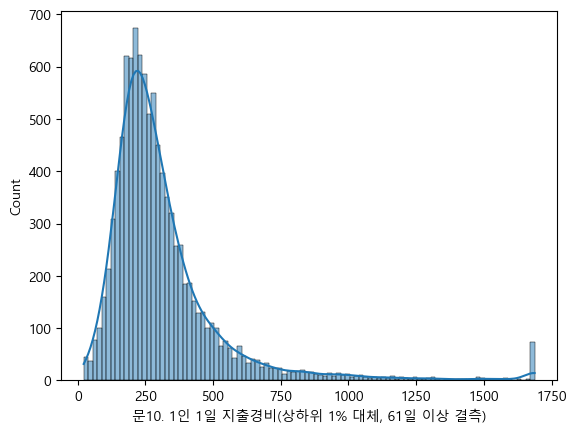

In [5]:
sns.histplot(df1['문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'], bins=100, kde=True)

**주요 이용 숙박시설**

- '숙박시설_그룹' -> 복합형인 경우 더 오래 머문 곳으로 넣기

In [6]:
# 0. 번호 → 숙박시설 이름 매핑 딕셔너리
stay_name_map = {
    "1": "호텔",
    "2": "모텔/여관",
    "3": "콘도미니엄/리조트",
    "4": "게스트하우스/호스텔",
    "5": "민박/펜션",
    "6": "학교/회사 기숙사, 연수원 등",
    "7": "친척 또는 친구 집",
    "8": "기타",
    "9": "숙박하지않음"
}

# 1. 컬럼 선택
stay_type_cols = [c for c in df2.columns if c.startswith('문9-5. 주요 이용 숙박시설_')]
stay_days_cols = [c for c in df2.columns if c.startswith('문9-5. 숙박시설별 숙박기간')]

# 2. 숙박기간 결측치 처리
df2[stay_days_cols] = df2[stay_days_cols].fillna(0).astype(float)

# 3. 매핑 딕셔너리 생성: 숙박시설 이름 → 숙박기간 컬럼
stay_mapping = {col.split('_')[-1]: col for col in stay_days_cols}

# 4. 함수 정의
def merge_stay_types(row):
    selected = []

    # '_1', '_2'에 표시된 값이 1이면 선택된 것
    for col in stay_type_cols:
        num = col.split('_')[-1]  # '문9..._1' → '1'
        name = stay_name_map.get(num)

        if name and (not pd.isna(row[col])) and row[col] != 0:
            selected.append(name)

    if len(selected) == 0:
        return np.nan
    elif len(selected) == 1:
        return selected[0]
    else:
        # 복수 선택 시 숙박기간 비교
        durations = {}
        for name in selected:
            day_col = stay_mapping.get(name)
            if day_col and day_col in row:
                durations[name] = row[day_col]

        if len(durations) > 0:
            return max(durations, key=durations.get)
        else:
            return '+'.join(selected)

# 5. 적용
df2['숙박시설_그룹'] = df2.apply(merge_stay_types, axis=1)

# 결과 확인
df2['숙박시설_그룹'].value_counts()


숙박시설_그룹
호텔                  8446
게스트하우스/호스텔           624
기타                   308
친척 또는 친구 집           258
모텔/여관                199
민박/펜션                192
콘도미니엄/리조트            110
숙박하지않음                14
학교/회사 기숙사, 연수원 등       5
Name: count, dtype: int64

In [7]:
# 1. df1에서 아이디 → 숙박시설_그룹 매핑 딕셔너리처럼 만들기
stay_map = df2.set_index('아이디')['숙박시설_그룹']

# 2. df의 숙박시설_그룹을 df1 기준으로 덮어쓰기
df2['숙박시설_그룹'] = df2['아이디'].map(stay_map)

df3 = df2.copy()

**여행 동반자**

- '여행그룹' 변수 -> 이상치 그룹은 하나로 묶어버리기.
- '여행그룹' 변수 -> '혼자', '커플', '자녀 or 부모님(추가 EDA) 동반 가족(자녀 포함된 모든 범주)', '성인 가족', '친구', '직장', '복합형(친구 + 가족)', '기타(나머지)'

In [8]:
import numpy as np
import pandas as pd  # 이미 있으면 생략

# 1) 문7. 동반자 유형 컬럼만 선택
partner_cols = [c for c in df3.columns if c.startswith('문7. 동반자 유형_')]

# 2) 번호 → 원래 선택지 텍스트 매핑
num_to_label = {
    1: '혼자 방문',
    2: '배우자/파트너',
    3: '부모님',
    4: '자녀',
    5: '그 외 가족/친지',
    6: '친구',
    7: '직장 동료',
    8: '기타'
}

In [9]:
# 0/1로 정리 (0이 아니면 1로)
X = df3[partner_cols].fillna(0).astype(int)
X = X.applymap(lambda x: 1 if x != 0 else 0)

# 각 행에서 어떤 동반자들이 선택되었는지 문자열로 합치기
def make_combo(row):
    labels = []
    for col in partner_cols:
        if row[col] == 1:
            num = int(col.split('_')[-1])     # '문7. 동반자 유형_3' → 3
            labels.append(num_to_label[num])  # 3 → '부모님'
    if len(labels) == 0:
        return ''   # 아무 것도 선택 안 한 경우
    return '+'.join(labels)

combo_series = X.apply(make_combo, axis=1)

# (원하면 조합 빈도 확인)
# combo_series.value_counts().head(20)


In [10]:
combo = combo_series.fillna('')

# 조건 설정
cond_혼자  = combo.str.contains('혼자', na=False)
cond_가족  = combo.str.contains('배우자|자녀|부모님|가족', na=False)
cond_친구  = combo.str.contains('친구', na=False)
cond_직장  = combo.str.contains('직장', na=False)
cond_기타  = combo.str.contains('기타', na=False)

# 복합형(가족+친구) 먼저!
conditions = [
    (cond_가족 & cond_친구),
    cond_가족,
    cond_친구,
    cond_혼자,
    cond_직장,
    cond_기타
]

choices = [
    '복합형(가족+친구)',
    '가족형',
    '친구형',
    '혼자형',
    '직장형',
    '기타형'
]

df3['여행동반자_그룹'] = np.select(conditions, choices, default='기타형')

df3['여행동반자_그룹'].value_counts()


여행동반자_그룹
가족형           4370
친구형           3394
혼자형           1611
직장형            435
복합형(가족+친구)     311
기타형             35
Name: count, dtype: int64

In [11]:
# 1. 분석에 사용할 컬럼 정의
group_col = '여행동반자_그룹'
count_col = '문7-1. 동반자 수(본인제외)' # 동반자 수 컬럼

# 2. (안전 조치) 동반자 수 컬럼을 숫자로 변환 (이미 되어있다면 생략 가능)
# 만약 숫자로 변환할 수 없는 값(예: '없음')이 있다면 NaN으로 바뀝니다.
df3[count_col] = pd.to_numeric(df3[count_col], errors='coerce')

# 3. 그룹별 IQR 및 이상치 상한선(Upper fence) 계산
# '혼자형'은 동반자 수가 0이므로 IQR 계산에서 제외합니다.
groups_to_check = df3[df3[group_col] != '혼자형'][group_col].unique()

# 그룹별 상한선을 저장할 딕셔너리
upper_fence_dict = {}

for group in groups_to_check:
    # 현재 그룹의 동반자 수 데이터 추출 (NaN 값 제외)
    group_data = df3.loc[df3[group_col] == group, count_col].dropna()
    
    # 데이터가 충분히 있어야 IQR 계산이 의미 있음
    if len(group_data) > 1:
        Q1 = group_data.quantile(0.25)
        Q3 = group_data.quantile(0.75)
        IQR = Q3 - Q1
        
        # 이상치 상한선 (Upper fence)
        upper_fence = Q3 + (1.5 * IQR)
        upper_fence_dict[group] = upper_fence
    else:
        # 데이터가 없거나 1개뿐이면, 상한선을 매우 큰 값으로 설정 (이상치 없음)
        upper_fence_dict[group] = np.inf

# 4. 계산된 상한선(upper_fence)을 df3에 매핑
# .map()을 사용하여 각 행의 '여행동반자_그룹'에 맞는 상한선을 새 컬럼으로 추가
df3['upper_fence'] = df3[group_col].map(upper_fence_dict)

# '혼자형'은 NaN이 되므로, np.inf (무한대)로 채워서 이상치로 분류되지 않게 함
df3['upper_fence'] = df3['upper_fence'].fillna(np.inf)

# 5. '단체형' 조건 정의
# 조건1: 동반자 수가 자신의 그룹별 상한선보다 크다
# 조건2: 동반자 수가 0이 아니다 (NaN 방지 및 논리적 확인)
cond_단체형 = (df3[count_col] > df3['upper_fence']) & (df3[count_col] > 0)

# 6. '단체형'으로 그룹 업데이트
# .loc를 사용하여 cond_단체형 조건에 맞는 행의 group_col 값을 '단체형'으로 변경
df3.loc[cond_단체형, group_col] = '단체형'

# 7. 결과 확인
print("--- '단체형' 적용 후 그룹 분포 ---")
print(df3[group_col].value_counts())

--- '단체형' 적용 후 그룹 분포 ---
여행동반자_그룹
가족형           4091
친구형           3042
혼자형           1611
단체형            650
직장형            416
복합형(가족+친구)     311
기타형             35
Name: count, dtype: int64


col drop

In [12]:
drop_col = ['upper_fence','문7. 동반자 유형_1',
 '문7. 동반자 유형_2',
 '문7. 동반자 유형_3',
 '문7. 동반자 유형_4',
 '문7. 동반자 유형_5',
 '문7. 동반자 유형_6',
 '문7. 동반자 유형_7',
 '문7. 동반자 유형_8', '문7-1. 동반자 수(본인제외)']
df3 = df3.drop(drop_col, axis=1)
df4 = df3.copy()

**시도별 체재기간**

- '총 체재기간' 변수 => 도메인 기반으로 직접 구간화하기(카테고리화)
- '방문 지역 수' 변수 추가 ''' 얼마나 다양한 지역을 방문했는지를 나타냅니다.
- '주요 체재 지역' 변수 추가
- '여행 패턴'은 일단 보류

In [13]:
stay_cols = [
    '문9-4. 시도별 체재기간_서울', '문9-4. 시도별 체재기간_경기', '문9-4. 시도별 체재기간_인천',
    '문9-4. 시도별 체재기간_강원', '문9-4. 시도별 체재기간_대전', '문9-4. 시도별 체재기간_충북',
    '문9-4. 시도별 체재기간_충남', '문9-4. 시도별 체재기간_세종', '문9-4. 시도별 체재기간_경북',
    '문9-4. 시도별 체재기간_경남', '문9-4. 시도별 체재기간_대구', '문9-4. 시도별 체재기간_울산',
    '문9-4. 시도별 체재기간_부산', '문9-4. 시도별 체재기간_광주', '문9-4. 시도별 체재기간_전북',
    '문9-4. 시도별 체재기간_전남', '문9-4. 시도별 체재기간_제주'
]
df4['방문 지역 수'] = (df4[stay_cols].fillna(0) > 0).sum(axis=1)

df4['주요 체재 지역'] = df4[stay_cols].idxmax(axis=1)
df4['주요 체재 지역'] = df4['주요 체재 지역'].str.replace('문9-4. 시도별 체재기간_', '', regex=False)

drop_col = [c for c in df4.columns if c.startswith('문9-4. 시도별 체재기간_')]
df4 = df4.drop(drop_col, axis=1)

df4.to_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2차_전처리.csv', index=False)

## 2) 3차

- 항목별 지출경비 추가

In [14]:
df = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2차_전처리.csv')
df.head()

,아이디,국가별,성별,연령별,문1. 주요 방한 목적,한국 방문횟수(카테고리),문1-1. 한국여행 관심 계기_1,문3-1. 고려한 관광활동_1,문3-2. 고려한 관광인프라_1,"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)",...,문9-5. 숙박시설별 숙박기간(60박 이상 결측)_콘도미니엄/리조트,문9-5. 숙박시설별 숙박기간(60박 이상 결측)_게스트하우스/호스텔,문9-5. 숙박시설별 숙박기간(60박 이상 결측)_민박/펜션,"문9-5. 숙박시설별 숙박기간(60박 이상 결측)_학교/회사 기숙사, 연수원 등",문9-5. 숙박시설별 숙박기간(60박 이상 결측)_친척 또는 친구 집,문9-5. 숙박시설별 숙박기간(60박 이상 결측)_기타,숙박시설_그룹,여행동반자_그룹,방문 지역 수,주요 체재 지역
0,57,13,2,5,1,4,7.0,1.0,3.0,451.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,호텔,가족형,1,서울
1,58,3,2,4,1,4,7.0,11.0,6.0,272.935000,...,0.0,0.0,0.0,0.0,0.0,0.0,호텔,가족형,1,서울
2,59,3,2,3,1,3,7.0,12.0,2.0,177.650000,...,0.0,0.0,0.0,0.0,0.0,0.0,호텔,단체형,1,서울
3,60,1,1,2,1,1,8.0,11.0,2.0,153.780000,...,0.0,0.0,0.0,0.0,0.0,0.0,호텔,혼자형,1,서울
4,61,3,2,2,1,4,2.0,1.0,4.0,329.460000,...,0.0,0.0,0.0,0.0,0.0,0.0,호텔,가족형,2,서울


In [15]:
df.drop(axis=1, columns=['문9-5. 주요 이용 숙박시설_1', '문9-5. 주요 이용 숙박시설_2', '문9-5. 주요 이용 숙박시설_3',
       '문9-5. 주요 이용 숙박시설_4', '문9-5. 주요 이용 숙박시설_5', '문9-5. 주요 이용 숙박시설_6',
       '문9-5. 주요 이용 숙박시설_7', '문9-5. 주요 이용 숙박시설_8', '문9-5. 주요 이용 숙박시설_9',
      '문9-5. 숙박시설별 숙박기간(60박 이상 결측)_호텔', '문9-5. 숙박시설별 숙박기간(60박 이상 결측)_모텔/여관',
       '문9-5. 숙박시설별 숙박기간(60박 이상 결측)_콘도미니엄/리조트',
       '문9-5. 숙박시설별 숙박기간(60박 이상 결측)_게스트하우스/호스텔',
       '문9-5. 숙박시설별 숙박기간(60박 이상 결측)_민박/펜션',
       '문9-5. 숙박시설별 숙박기간(60박 이상 결측)_학교/회사 기숙사, 연수원 등',
       '문9-5. 숙박시설별 숙박기간(60박 이상 결측)_친척 또는 친구 집',
       '문9-5. 숙박시설별 숙박기간(60박 이상 결측)_기타'], inplace=True)

**항목별 지출 경비 추가**

In [16]:
df1 = df.copy()


tmp = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_만족도조사.csv', encoding='cp949')

col = ['아이디',
    '문10-1. 항목별 지출경비(상하위 1% 대체)_여행사에 지불한 경비', '문10-1. 항목별 지출경비(상하위 1% 대체)_가이드 비용/가이드 팁',
'문10-1. 항목별 지출경비(상하위 1% 대체)_숙박비', '문10-1. 항목별 지출경비(상하위 1% 대체)_음식점 지출비',
'문10-1. 항목별 지출경비(상하위 1% 대체)_식음료/식재료 구매 비용',
'문10-1. 항목별 지출경비(상하위 1% 대체)_국제교통비_항공비(국적기)',
'문10-1. 항목별 지출경비(상하위 1% 대체)_국제교통비_항공비(국적기 외)',
'문10-1. 항목별 지출경비(상하위 1% 대체)_국제교통비_수상 여객운송',
'문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_항공비(국적기)',
'문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_항공비(국적기 외)',
'문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_수상 여객운송',
'문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_철도 여객운송',
'문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_도로 여객운송',
'문10-1. 항목별 지출경비(상하위 1% 대체)_운송장비 대여서비스',
'문10-1. 항목별 지출경비(상하위 1% 대체)_유류비',
'문10-1. 항목별 지출경비(상하위 1% 대체)_문화서비스',
'문10-1. 항목별 지출경비(상하위 1% 대체)_오락 및 운동관련 서비스',
'문10-1. 항목별 지출경비(상하위 1% 대체)_쇼핑비',
'문10-1. 항목별 지출경비(상하위 1% 대체)_데이터 통신비',
'문10-1. 항목별 지출경비(상하위 1% 대체)_치료 및 건강검진비',
'문10-1. 항목별 지출경비(상하위 1% 대체)_미용 서비스비',
'문10-1. 항목별 지출경비(상하위 1% 대체)_기타 비용'
    ]

tmp = tmp[col]

df1 = pd.merge(left=df1, right=tmp, how='inner', on='아이디')
df1.head()

,아이디,국가별,성별,연령별,문1. 주요 방한 목적,한국 방문횟수(카테고리),문1-1. 한국여행 관심 계기_1,문3-1. 고려한 관광활동_1,문3-2. 고려한 관광인프라_1,"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)",...,문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_도로 여객운송,문10-1. 항목별 지출경비(상하위 1% 대체)_운송장비 대여서비스,문10-1. 항목별 지출경비(상하위 1% 대체)_유류비,문10-1. 항목별 지출경비(상하위 1% 대체)_문화서비스,문10-1. 항목별 지출경비(상하위 1% 대체)_오락 및 운동관련 서비스,문10-1. 항목별 지출경비(상하위 1% 대체)_쇼핑비,문10-1. 항목별 지출경비(상하위 1% 대체)_데이터 통신비,문10-1. 항목별 지출경비(상하위 1% 대체)_치료 및 건강검진비,문10-1. 항목별 지출경비(상하위 1% 대체)_미용 서비스비,문10-1. 항목별 지출경비(상하위 1% 대체)_기타 비용
0,57,13,2,5,1,4,7.0,1.0,3.0,451.666667,...,100.000000,0.0,0.0,0.00000,50.000000,500.000000,0.000000,0.0,0.0,0.0
1,58,3,2,4,1,4,7.0,11.0,6.0,272.935000,...,24.295442,0.0,0.0,4.04924,0.000000,485.908848,8.098481,0.0,0.0,0.0
2,59,3,2,3,1,3,7.0,12.0,2.0,177.650000,...,32.295107,0.0,0.0,0.00000,32.295107,322.951068,8.073777,0.0,0.0,0.0
3,60,1,1,2,1,1,8.0,11.0,2.0,153.780000,...,27.917700,0.0,0.0,0.00000,0.000000,139.588502,0.000000,0.0,0.0,0.0
4,61,3,2,2,1,4,2.0,1.0,4.0,329.460000,...,32.293668,0.0,0.0,0.00000,0.000000,968.810037,16.146834,0.0,0.0,0.0


In [17]:
food_cols =['문10-1. 항목별 지출경비(상하위 1% 대체)_음식점 지출비',
            '문10-1. 항목별 지출경비(상하위 1% 대체)_식음료/식재료 구매 비용']
# 국제교통비 제외
transport_cols = [
    '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_항공비(국적기)',
    '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_항공비(국적기 외)',
    '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_수상 여객운송',
    '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_철도 여객운송',
    '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_도로 여객운송',
    '문10-1. 항목별 지출경비(상하위 1% 대체)_운송장비 대여서비스',
    '문10-1. 항목별 지출경비(상하위 1% 대체)_유류비'
]
activity_cols = [
    '문10-1. 항목별 지출경비(상하위 1% 대체)_문화서비스',
    '문10-1. 항목별 지출경비(상하위 1% 대체)_오락 및 운동관련 서비스'
]
beauty_medical_cols = [
    '문10-1. 항목별 지출경비(상하위 1% 대체)_치료 및 건강검진비',
    '문10-1. 항목별 지출경비(상하위 1% 대체)_미용 서비스비'
]
service_cols = [
    '문10-1. 항목별 지출경비(상하위 1% 대체)_여행사에 지불한 경비',
    '문10-1. 항목별 지출경비(상하위 1% 대체)_가이드 비용/가이드 팁'
]
other_cols = [
    '문10-1. 항목별 지출경비(상하위 1% 대체)_데이터 통신비',
    '문10-1. 항목별 지출경비(상하위 1% 대체)_기타 비용'
]

In [18]:
df1['Agg_식비'] = df1[food_cols].fillna(0).sum(axis=1)
df1['Agg_국내 교통비'] = df1[transport_cols].fillna(0).sum(axis=1)
df1['Agg_체험/활동비'] = df1[activity_cols].fillna(0).sum(axis=1)
df1['Agg_뷰티/의료비'] = df1[beauty_medical_cols].fillna(0).sum(axis=1)
df1['Agg_여행 서비스비'] = df1[service_cols].fillna(0).sum(axis=1)
df1['Agg_숙박비'] = df1['문10-1. 항목별 지출경비(상하위 1% 대체)_숙박비'].fillna(0)
df1['Agg_쇼핑비'] = df1['문10-1. 항목별 지출경비(상하위 1% 대체)_쇼핑비'].fillna(0)
df1['Agg_기타 비용'] = df1[other_cols].fillna(0).sum(axis=1)

In [19]:
agg_cols_list = [
    'Agg_식비', 'Agg_국내 교통비', 'Agg_체험/활동비', 'Agg_뷰티/의료비',
    'Agg_여행 서비스비', 'Agg_숙박비', 'Agg_쇼핑비', 'Agg_기타 비용'
]

df1['총 국내 지출경비'] = df1[agg_cols_list].sum(axis=1)

In [20]:
new_ratio_cols = []
for col in agg_cols_list:
    ratio_col_name = col.replace('Agg_', '') + '_비율' # 예: 'Agg_총 식비' -> '총 식비_비율'
    df1[ratio_col_name] = np.where(
        df1['총 국내 지출경비'] == 0,  # 만약 총 지출이 0이면
        0,                               # 비율도 0으로
        df1[col] / df1['총 국내 지출경비'] # 아니면 (항목 지출 / 총 지출) 계산
    )
    new_ratio_cols.append(ratio_col_name)

In [21]:
cols = ['문10-1. 항목별 지출경비(상하위 1% 대체)_여행사에 지불한 경비',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_가이드 비용/가이드 팁',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_숙박비', '문10-1. 항목별 지출경비(상하위 1% 대체)_음식점 지출비',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_식음료/식재료 구매 비용',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_국제교통비_항공비(국적기)',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_국제교통비_항공비(국적기 외)',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_국제교통비_수상 여객운송',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_항공비(국적기)',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_항공비(국적기 외)',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_수상 여객운송',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_철도 여객운송',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_도로 여객운송',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_운송장비 대여서비스',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_유류비', '문10-1. 항목별 지출경비(상하위 1% 대체)_문화서비스',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_오락 및 운동관련 서비스',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_쇼핑비', '문10-1. 항목별 지출경비(상하위 1% 대체)_데이터 통신비',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_치료 및 건강검진비',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_미용 서비스비',
       '문10-1. 항목별 지출경비(상하위 1% 대체)_기타 비용',
       'Agg_식비', 'Agg_국내 교통비', 'Agg_체험/활동비', 'Agg_뷰티/의료비',
       'Agg_여행 서비스비', 'Agg_숙박비', 'Agg_쇼핑비', 'Agg_기타 비용']

df1.drop(cols, axis=1, inplace=True)
df1.shape

df1.to_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_3차_전처리.csv', index=False)

## 3) 4차
- 구간화 => ‘1인 1일 지출경비’, ‘총 체제기간’
- 항목별 지출경비 "비율"로 전환
- 항목 묶기 매핑 => 한국여행 관심 계기, 고려한 관광활동, 고려한 관광인프라

In [22]:
df = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_3차_전처리.csv')

**1인 1일 지출경비 구간화**

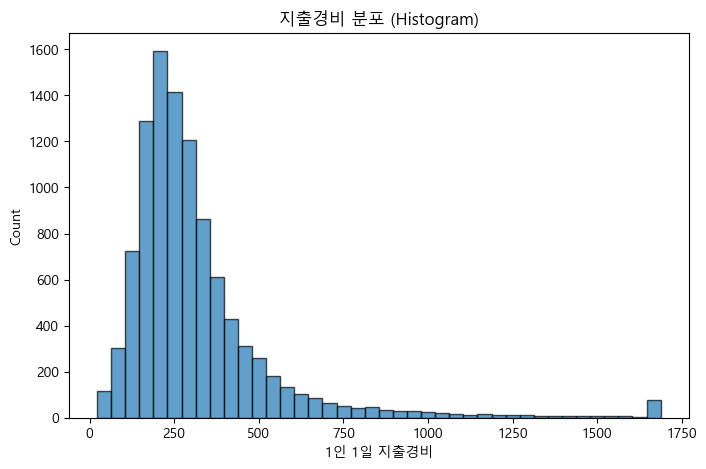

In [23]:
target_col = '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'

plt.figure(figsize=(8,5))
plt.hist(df[target_col], bins=40, edgecolor='black', alpha=0.7)
plt.xlabel('1인 1일 지출경비')
plt.ylabel('Count')
plt.title('지출경비 분포 (Histogram)')
plt.show()

In [24]:
quantiles = np.arange(0, 1.01, 0.05)   # 0%, 5%, 10%, ..., 100%
q_table = df[target_col].quantile(quantiles)

q_df = q_table.reset_index()
q_df.columns = ['Quantile', 'Value']
q_df

,Quantile,Value
0,0.00,22.000000
1,0.05,112.911306
2,0.10,140.745000
3,0.15,162.446680
4,0.20,178.666667
5,0.25,191.987819
6,0.30,205.316750
7,0.35,217.932500
8,0.40,231.000000
9,0.45,244.400000


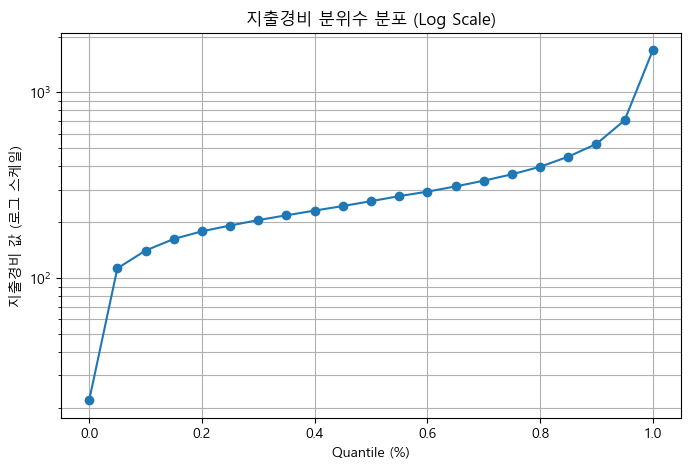

In [25]:
plt.figure(figsize=(8,5))
plt.plot(q_df['Quantile'], q_df['Value'], marker='o')
plt.yscale('log')
plt.xlabel('Quantile (%)')
plt.ylabel('지출경비 값 (로그 스케일)')
plt.title('지출경비 분위수 분포 (Log Scale)')
plt.grid(True, which='both')
plt.show()

In [26]:
# q_df 는 다음 형태로 이미 존재한다:
# Quantile | Value

q = q_df['Quantile'].values
v = q_df['Value'].values

# 인접 분위수 간 차이 계산
diff = np.diff(v)  # Value 차이
step = np.diff(q)  # Quantile 차이 (여기서는 전부 5씩)

# 기울기(증가량) = diff / step 이지만 step은 일정하므로 diff 자체로 비교 가능
slope = diff / step

# 구간 테이블 생성
slope_df = pd.DataFrame({
    'q_start': q[:-1],
    'q_end': q[1:],
    'v_start': v[:-1],
    'v_end': v[1:],
    'diff': diff,
    'slope': slope
})

# 기울기 큰 순으로 7개 구간 추출
top7 = slope_df.reindex(slope_df['slope'].abs().sort_values(ascending=False).index).head(7)

top7

# 90 ~ 100 %
# 65 ~ 90 %
# 55 ~ 65 %
# 15 ~ 55 %
# 5 ~ 15 %
# 0 ~ 5 %

,q_start,q_end,v_start,v_end,diff,slope
19,0.95,1.00,708.250000,1687.500000,979.250000,19585.000000
18,0.90,0.95,528.034286,708.250000,180.215714,3604.314286
0,0.00,0.05,22.000000,112.911306,90.911306,1818.226129
17,0.85,0.90,450.973594,528.034286,77.060692,1541.213839
16,0.80,0.85,397.650000,450.973594,53.323594,1066.471875
15,0.75,0.80,362.264875,397.650000,35.385125,707.702500
1,0.05,0.10,112.911306,140.745000,27.833694,556.673871


In [27]:
### 구간화 ###

col = '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'

# 분위수 기준값
# p20 = 106.08
# p50 = 177.765
# p80 = 298.14
# p90 = 400
# p95 = 540.9375

p5 = 112.911306
p75 = 362.264875
p90 = 528.034286
p100 = 1687.500000

def segment(x):
    if x < p5:
        return 1
    elif x < p75:
        return 2
    elif x < p90:
        return 3
    # elif x < p90:
    #     return 4
    # elif x < p95:
    #     return 5
    else:
        return 4

df[col] = df[col].apply(segment)


df['문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'].value_counts()

문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)
2    7109
3    1523
4    1016
1     508
Name: count, dtype: int64

**총 체재기간 구간화**

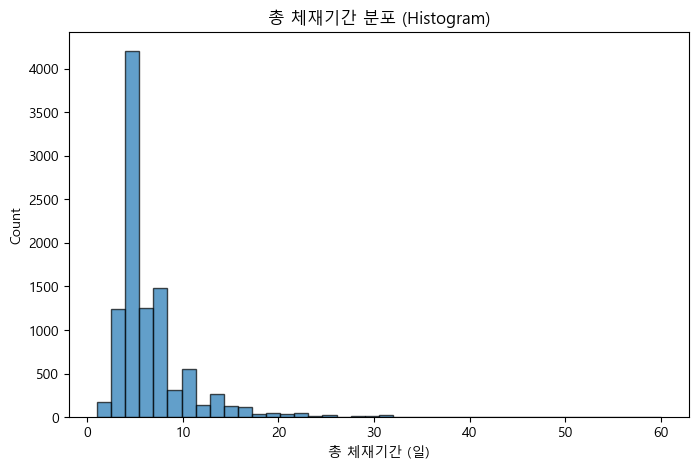

In [28]:
target_col2 = '문9-3. 총 체재기간_61일 이상 결측'

plt.figure(figsize=(8,5))
plt.hist(df[target_col2], bins=40, edgecolor='black', alpha=0.7)
plt.xlabel('총 체재기간 (일)')
plt.ylabel('Count')
plt.title('총 체재기간 분포 (Histogram)')
plt.show()

In [29]:
quantiles = np.arange(0, 1.01, 0.05)   # 0%, 5%, 10%, ..., 100%
q_table2 = df[target_col2].quantile(quantiles)

q_df2 = q_table2.reset_index()
q_df2.columns = ['Quantile', 'Value']
q_df2

,Quantile,Value
0,0.00,1.0
1,0.05,3.0
2,0.10,3.0
3,0.15,4.0
4,0.20,4.0
5,0.25,4.0
6,0.30,4.0
7,0.35,5.0
8,0.40,5.0
9,0.45,5.0


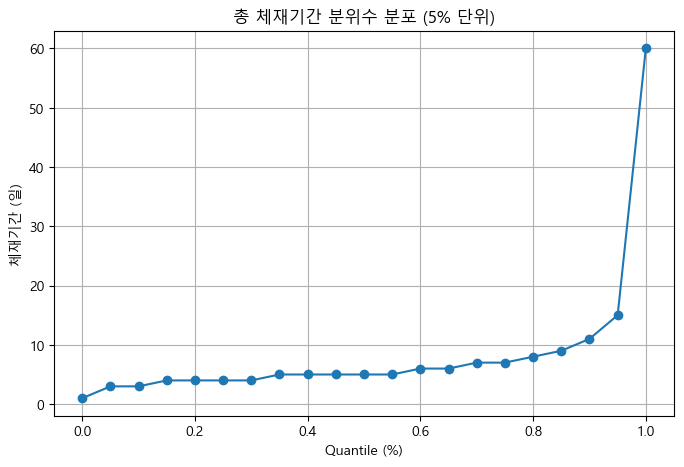

In [30]:
plt.figure(figsize=(8,5))
plt.plot(q_df2['Quantile'], q_df2['Value'], marker='o')
plt.xlabel('Quantile (%)')
plt.ylabel('체재기간 (일)')
plt.title('총 체재기간 분위수 분포 (5% 단위)')
plt.grid(True)
plt.show()

In [31]:
q = q_df2['Quantile'].values
v = q_df2['Value'].values

# 인접 분위수 간 차이 계산
diff = np.diff(v)      # Value 차이
step = np.diff(q)      # Quantile 차이 (여기서는 전부 5씩 일정)

# 기울기(증가량) = diff / step (step 일정이라 diff로 비교해도 동일)
slope = diff / step

# 구간 테이블 생성
slope_df2 = pd.DataFrame({
    'q_start': q[:-1],
    'q_end': q[1:],
    'v_start': v[:-1],
    'v_end': v[1:],
    'diff': diff,
    'slope': slope
})

# 기울기(절댓값) 큰 순으로 상위 7개 구간 추출
top7_stay = slope_df2.reindex(slope_df2['slope'].abs().sort_values(ascending=False).index)

top7_stay

,q_start,q_end,v_start,v_end,diff,slope
19,0.95,1.00,15.0,60.0,45.0,900.0
18,0.90,0.95,11.0,15.0,4.0,80.0
17,0.85,0.90,9.0,11.0,2.0,40.0
0,0.00,0.05,1.0,3.0,2.0,40.0
6,0.30,0.35,4.0,5.0,1.0,20.0
2,0.10,0.15,3.0,4.0,1.0,20.0
11,0.55,0.60,5.0,6.0,1.0,20.0
13,0.65,0.70,6.0,7.0,1.0,20.0
15,0.75,0.80,7.0,8.0,1.0,20.0
16,0.80,0.85,8.0,9.0,1.0,20.0


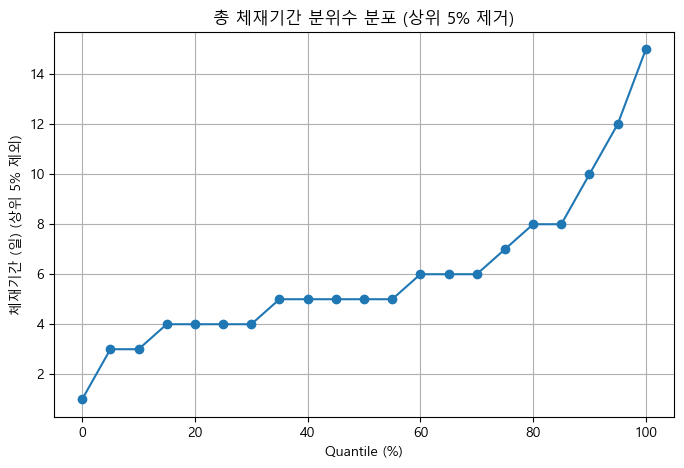

In [32]:
# 상위 5% cutoff
cut2 = df[target_col2].quantile(0.95)
# 상위 5% 제외한 데이터로 재분석
df_trim2 = df[df[target_col2] <= cut2]
quantiles = np.arange(0, 1.01, 0.05)
q_table_trim2 = df_trim2[target_col2].quantile(quantiles)
q_df_trim2 = q_table_trim2.reset_index()
q_df_trim2.columns = ['Quantile', 'Value']
q_df_trim2['Quantile'] = q_df_trim2['Quantile'] * 100  # % 변환
plt.figure(figsize=(8,5))
plt.plot(q_df_trim2['Quantile'], q_df_trim2['Value'], marker='o')
plt.xlabel('Quantile (%)')
plt.ylabel('체재기간 (일) (상위 5% 제외)')
plt.title('총 체재기간 분위수 분포 (상위 5% 제거)')
plt.grid(True)
plt.show()

In [33]:
### 구간화 ###

col = '문9-3. 총 체재기간_61일 이상 결측'

segments = []

for x in df[col]:
    if 1 <= x <= 3:
        segments.append(1)
    elif 4 <= x <= 5:
        segments.append(2)
    elif 6 <= x <= 8:
        segments.append(3)
    # elif 8 <= x <= 11:
    #     segments.append(4)
    # elif 12 <= x <= 17:
    #     segments.append(5)
    elif x > 8:
        segments.append(4)
    else:
        segments.append(np.nan)  # 혹시 0이나 이상값 있을 때 대비


df['문9-3. 총 체재기간_61일 이상 결측'] = segments
df['문9-3. 총 체재기간_61일 이상 결측'].value_counts()

문9-3. 총 체재기간_61일 이상 결측
2    4207
3    2735
4    1804
1    1410
Name: count, dtype: int64

**항목별 지출경비 비율**

In [34]:
import pandas as pd

df1 = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_만족도조사.csv', encoding = 'cp949')
df1 = df1[df1['문1. 주요 방한 목적'] == 1]


# 1. df1에서 지출 컬럼 자동 선택
expense_cols = [col for col in df1.columns if col.startswith('문10-1. 항목별 지출경비(상하위 1% 대체)_')]
# 2. ID + 선택된 컬럼만 유지
df1_use = df1[['아이디'] + expense_cols]
# 3. merge
df = df.merge(df1_use, on='아이디', how='left')

In [35]:
expense_groups = {
    '식비': [
        '문10-1. 항목별 지출경비(상하위 1% 대체)_음식점 지출비',
        '문10-1. 항목별 지출경비(상하위 1% 대체)_식음료/식재료 구매 비용'
    ],

    '여행_가이드': [
        '문10-1. 항목별 지출경비(상하위 1% 대체)_여행사에 지불한 경비',
        '문10-1. 항목별 지출경비(상하위 1% 대체)_가이드 비용/가이드 팁'
    ],

    '숙박': [
        '문10-1. 항목별 지출경비(상하위 1% 대체)_숙박비'
    ],

    '교통': [
        '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_항공비(국적기)',
        '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_항공비(국적기 외)',
        '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_수상 여객운송',
        '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_철도 여객운송',
        '문10-1. 항목별 지출경비(상하위 1% 대체)_한국에서의 교통비_도로 여객운송',
        '문10-1. 항목별 지출경비(상하위 1% 대체)_운송장비 대여서비스',
        '문10-1. 항목별 지출경비(상하위 1% 대체)_유류비'
    ],

    '체험_문화': [
        '문10-1. 항목별 지출경비(상하위 1% 대체)_문화서비스',
        '문10-1. 항목별 지출경비(상하위 1% 대체)_오락 및 운동관련 서비스'
    ],

    '쇼핑': [
        '문10-1. 항목별 지출경비(상하위 1% 대체)_쇼핑비'
    ],

    '기타': [
        '문10-1. 항목별 지출경비(상하위 1% 대체)_데이터 통신비',
        '문10-1. 항목별 지출경비(상하위 1% 대체)_기타 비용'
    ],

    '뷰티/의료': [
        '문10-1. 항목별 지출경비(상하위 1% 대체)_치료 및 건강검진비',
        '문10-1. 항목별 지출경비(상하위 1% 대체)_미용 서비스비'
    ]
}


# 그룹별 지출 합 변수 생성
for group, cols in expense_groups.items():
    df[f'총_{group}_지출경비'] = df[cols].sum(axis=1)


# 총 국내 지출경비 생성
df['총_국내_지출경비'] = df[[f'총_{g}_지출경비' for g in expense_groups]].sum(axis=1)
df['총_국내_지출경비']


# 비율 변수 생성
for group in expense_groups.keys():
    df[f'{group}_비율'] = (df[f'총_{group}_지출경비'] / df['총_국내_지출경비']).round(3)

# 기존 컬럼 삭제
drop_cols = [col for col in df.columns
             if col.startswith('문10-1. 항목별 지출경비(상하위 1% 대체)_')]

df = df.drop(columns=drop_cols)
df = df.drop(columns= ['문1. 주요 방한 목적'])
df.columns

Index(['아이디', '국가별', '성별', '연령별', '한국 방문횟수(카테고리)', '문1-1. 한국여행 관심 계기_1',
       '문3-1. 고려한 관광활동_1', '문3-2. 고려한 관광인프라_1',
       '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)', '문9-3. 총 체재기간_61일 이상 결측',
       '숙박시설_그룹', '여행동반자_그룹', '방문 지역 수', '주요 체재 지역', '총 국내 지출경비', '식비_비율',
       '국내 교통비_비율', '체험/활동비_비율', '뷰티/의료비_비율', '여행 서비스비_비율', '숙박비_비율', '쇼핑비_비율',
       '기타 비용_비율', '총_식비_지출경비', '총_여행_가이드_지출경비', '총_숙박_지출경비', '총_교통_지출경비',
       '총_체험_문화_지출경비', '총_쇼핑_지출경비', '총_기타_지출경비', '총_뷰티/의료_지출경비', '총_국내_지출경비',
       '여행_가이드_비율', '숙박_비율', '교통_비율', '체험_문화_비율', '쇼핑_비율', '기타_비율',
       '뷰티/의료_비율'],
      dtype='object')

In [36]:
cols = ['총 국내 지출경비', '총_식비_지출경비', '총_여행_가이드_지출경비', '총_숙박_지출경비', '총_교통_지출경비',
       '총_체험_문화_지출경비', '총_쇼핑_지출경비', '총_기타_지출경비', '총_뷰티/의료_지출경비', '총_국내_지출경비',
       '여행_가이드_비율', '숙박_비율', '교통_비율', '체험_문화_비율', '쇼핑_비율', '기타_비율',
       '뷰티/의료_비율']


df.drop(columns=cols, inplace=True)

**구간화 매핑**

In [37]:
mapping = {
    1: 1,
    2: 2,
    3: 3,
    4: 4, 10: 4,
    5: 5, 6: 5,
    7: 6,
    8: 7, 9: 7,
    11: 8
}

df['문1-1. 한국여행 관심 계기_1'] = df['문1-1. 한국여행 관심 계기_1'].map(mapping)
df['문1-1. 한국여행 관심 계기_1'].value_counts()

문1-1. 한국여행 관심 계기_1
1    2543
6    1918
7    1710
2    1374
4    1059
5     975
3     354
8     223
Name: count, dtype: int64

In [38]:
mapping = {
    1: 1,
    2: 2,
    3: 3,
    4: 4, 5: 4,
    6: 5, 8: 5,
    7: 6,
    14: 7, 15: 7,
    9: 8,
    10:9, 11:9,
    12:10, 13:10,
    16:11
}

df['문3-1. 고려한 관광활동_1'] = df['문3-1. 고려한 관광활동_1'].map(mapping)
df['문3-1. 고려한 관광활동_1'].value_counts()

문3-1. 고려한 관광활동_1
2.0     1984
1.0     1613
5.0     1429
4.0     1329
10.0    1318
3.0     1169
9.0      440
6.0      394
7.0      297
8.0       95
11.0      70
Name: count, dtype: int64

In [39]:
mapping = {
    1: 1,
    2: 2,
    3: 3,
    4: 4,
    5: 5,
    6: 6, 8:6,
    7: 7,
    9:8, 10:8, 11:8,
    12:9
}

df['문3-2. 고려한 관광인프라_1'] = df['문3-2. 고려한 관광인프라_1'].map(mapping)
df['문3-2. 고려한 관광인프라_1'].value_counts()

문3-2. 고려한 관광인프라_1
6    2369
3    1965
8    1387
4    1372
5    1197
2     873
1     747
7     169
9      77
Name: count, dtype: int64

In [40]:
df.to_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_4차_전처리.csv', index=False)

## 4) 5차
- eda 진행. 주요 변수 변환 x

## 5) 6차
- ‘1인 1일 지출경비’/ 문9-3. 총 체재기간_61일 이상 결측 => 구간화 풀기
- '여행 패턴' + '체류 기간'해서 기존의 여행 패턴 변수를 수정 - 서울단기형/서울심층형/ 수도권
- 컬럼 삭제 : 주요 체재지역 / 문9-3. 총 체재기간

**‘1인 1일 지출경비’/ 문9-3. 총 체재기간_61일 이상 결측 => 구간화 풀기**

In [41]:
df = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_4차_전처리.csv')
raw = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_만족도조사.csv', encoding='cp949')

In [42]:
# raw['문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'].unique()
# df['문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'].unique()
# df[df['문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'].isna()]
# sorted(raw['문9-3. 총 체재기간'], reverse=True)

In [43]:
raw.filter(like='문10. 1인')

,문10. 1인 지출경비(상하위 1% 대체),"문10. 1인 지출경비(상하위 1% 대체, 카테고리)","문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)","문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측, 카테고리)"
0,2710.000,3,451.666667,4.0
1,1364.675,2,272.935000,3.0
2,1065.900,2,177.650000,3.0
3,922.680,1,153.780000,3.0
4,1647.300,2,329.460000,4.0
...,...,...,...,...
16211,562.930,1,112.586000,3.0
16212,335.520,1,52.860500,2.0
16213,2677.350,3,535.470000,5.0
16214,755.150,1,151.030000,3.0


In [44]:
df.drop(columns=['문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)', '문9-3. 총 체재기간_61일 이상 결측'], inplace=True)

cols = ['아이디', '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)', '문9-3. 총 체재기간_61일 이상 결측']
df = pd.merge(left=df, right=raw[cols], on='아이디', how='inner')

df.columns

Index(['아이디', '국가별', '성별', '연령별', '한국 방문횟수(카테고리)', '문1-1. 한국여행 관심 계기_1',
       '문3-1. 고려한 관광활동_1', '문3-2. 고려한 관광인프라_1', '숙박시설_그룹', '여행동반자_그룹',
       '방문 지역 수', '주요 체재 지역', '식비_비율', '국내 교통비_비율', '체험/활동비_비율', '뷰티/의료비_비율',
       '여행 서비스비_비율', '숙박비_비율', '쇼핑비_비율', '기타 비용_비율',
       '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)', '문9-3. 총 체재기간_61일 이상 결측'],
      dtype='object')

**여행 패턴 변수**

In [45]:
cols = ['아이디', '문9-3. 총 체재기간']
raw = raw[cols]

df1 = pd.merge(left=df, right=raw, on='아이디', how='inner')

conditions = [(df1['주요 체재 지역']!='서울'),
              (df1['주요 체재 지역']=='서울') & (df1['문9-3. 총 체재기간']<=5),
              (df1['주요 체재 지역']=='서울') & (df1['문9-3. 총 체재기간']>5)]
choices = ['수도권/지방형(탐험가형)',
           '서울 단기형',
           '서울 심층형']
df1['여행 패턴'] = np.select(conditions, choices, default='기타')
df1.head()


,아이디,국가별,성별,연령별,한국 방문횟수(카테고리),문1-1. 한국여행 관심 계기_1,문3-1. 고려한 관광활동_1,문3-2. 고려한 관광인프라_1,숙박시설_그룹,여행동반자_그룹,...,체험/활동비_비율,뷰티/의료비_비율,여행 서비스비_비율,숙박비_비율,쇼핑비_비율,기타 비용_비율,"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)",문9-3. 총 체재기간_61일 이상 결측,문9-3. 총 체재기간,여행 패턴
0,57,13,2,5,4,6,1.0,3,호텔,가족형,...,0.021645,0.0,0.004329,0.432900,0.216450,0.000000,451.666667,6.0,6,서울 심층형
1,58,3,2,4,4,6,9.0,6,호텔,가족형,...,0.004784,0.0,0.000096,0.239212,0.574108,0.009568,272.935000,5.0,5,서울 단기형
2,59,3,2,3,3,6,10.0,2,호텔,단체형,...,0.043469,0.0,0.000217,0.217344,0.434688,0.010867,177.650000,6.0,6,서울 심층형
3,60,1,1,2,1,7,9.0,2,호텔,혼자형,...,0.000000,0.0,0.001919,0.383877,0.191939,0.000000,153.780000,6.0,6,서울 심층형
4,61,3,2,2,4,2,1.0,4,호텔,가족형,...,0.000000,0.0,0.000256,0.128172,0.769034,0.012817,329.460000,5.0,5,서울 단기형


**컬럼 삭제**

In [46]:
df = df1.drop(columns = ['문9-3. 총 체재기간', '주요 체재 지역'])

In [47]:
df.to_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_6차_전처리.csv', encoding = 'utf-8')

## 6) 7차
- 범주형 변수 전처리(한국여행 관심계기 / 고려한 관광활동 / 고려한 관광인프라)
- 컬럼 삭제 :  _비율

In [48]:
df = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_6차_전처리.csv')

**컬럼 삭제**

In [49]:
cols = ['숙박시설_그룹', '식비_비율', '국내 교통비_비율', '체험/활동비_비율', '뷰티/의료비_비율', '여행 서비스비_비율',
       '숙박비_비율', '쇼핑비_비율', '기타 비용_비율']

df.drop(columns=cols, inplace=True)
df.columns

Index(['Unnamed: 0', '아이디', '국가별', '성별', '연령별', '한국 방문횟수(카테고리)',
       '문1-1. 한국여행 관심 계기_1', '문3-1. 고려한 관광활동_1', '문3-2. 고려한 관광인프라_1',
       '여행동반자_그룹', '방문 지역 수', '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)',
       '문9-3. 총 체재기간_61일 이상 결측', '여행 패턴'],
      dtype='object')

**문1-1. 한국여행 관심계기**
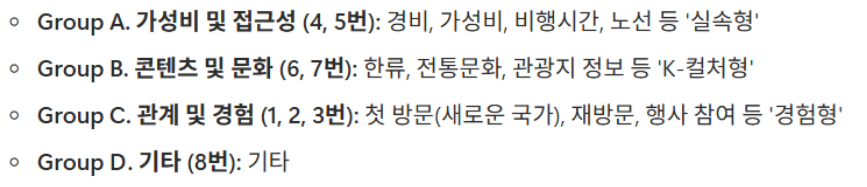

In [50]:
df['문1-1. 한국여행 관심 계기_1'].unique()

array([6, 7, 2, 5, 4, 1, 8, 3], dtype=int64)

In [51]:
df['문1-1. 한국여행 관심 계기_1'] = df['문1-1. 한국여행 관심 계기_1'].replace({
    4:'가성비 및 접근성', 5:'가성비 및 접근성',
    6: '콘텐츠 및 문화', 7: '콘텐츠 및 문화',
    1: '경험형', 2: '경험형', 3: '경험형',
    8: '기타'})

df['문1-1. 한국여행 관심 계기_1'].unique()

array(['콘텐츠 및 문화', '경험형', '가성비 및 접근성', '기타'], dtype=object)

**문3-1. 고려한 관광활동**
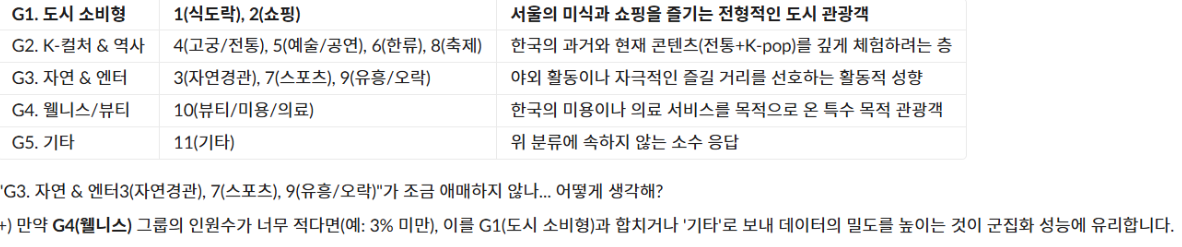

In [52]:
raw = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_만족도조사.csv', encoding='cp949')
raw123 = raw[['아이디', '문3-1. 고려한 관광활동_1', '문3-1. 고려한 관광활동_2', '문3-1. 고려한 관광활동_3']]
raw123.head()

,아이디,문3-1. 고려한 관광활동_1,문3-1. 고려한 관광활동_2,문3-1. 고려한 관광활동_3
0,57,1.0,2.0,NaN
1,58,11.0,2.0,1.0
2,59,12.0,5.0,2.0
3,60,11.0,2.0,6.0
4,61,1.0,NaN,NaN


In [53]:
df.drop(columns = '문3-1. 고려한 관광활동_1', inplace = True)

In [54]:
activity = pd.merge(left=df, right=raw123, on='아이디', how='inner')
activity

,Unnamed: 0,아이디,국가별,성별,연령별,한국 방문횟수(카테고리),문1-1. 한국여행 관심 계기_1,문3-2. 고려한 관광인프라_1,여행동반자_그룹,방문 지역 수,"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)",문9-3. 총 체재기간_61일 이상 결측,여행 패턴,문3-1. 고려한 관광활동_1,문3-1. 고려한 관광활동_2,문3-1. 고려한 관광활동_3
0,0,57,13,2,5,4,콘텐츠 및 문화,3,가족형,1,451.666667,6.0,서울 심층형,1.0,2.0,NaN
1,1,58,3,2,4,4,콘텐츠 및 문화,6,가족형,1,272.935000,5.0,서울 단기형,11.0,2.0,1.0
2,2,59,3,2,3,3,콘텐츠 및 문화,2,단체형,1,177.650000,6.0,서울 심층형,12.0,5.0,2.0
3,3,60,1,1,2,1,콘텐츠 및 문화,2,혼자형,1,153.780000,6.0,서울 심층형,11.0,2.0,6.0
4,4,61,3,2,2,4,경험형,4,가족형,2,329.460000,5.0,서울 단기형,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10151,10151,19271,1,2,2,1,가성비 및 접근성,3,친구형,1,126.316000,5.0,수도권/지방형(탐험가형),3.0,1.0,4.0
10152,10152,19273,1,2,4,2,가성비 및 접근성,5,친구형,1,112.586000,5.0,수도권/지방형(탐험가형),3.0,2.0,1.0
10153,10153,19274,1,1,4,2,콘텐츠 및 문화,4,가족형,1,52.860500,5.0,수도권/지방형(탐험가형),12.0,3.0,1.0
10154,10154,19275,1,2,5,1,가성비 및 접근성,7,가족형,1,535.470000,5.0,수도권/지방형(탐험가형),13.0,NaN,NaN


<Axes: xlabel='문3-1. 고려한 관광활동_1', ylabel='count'>

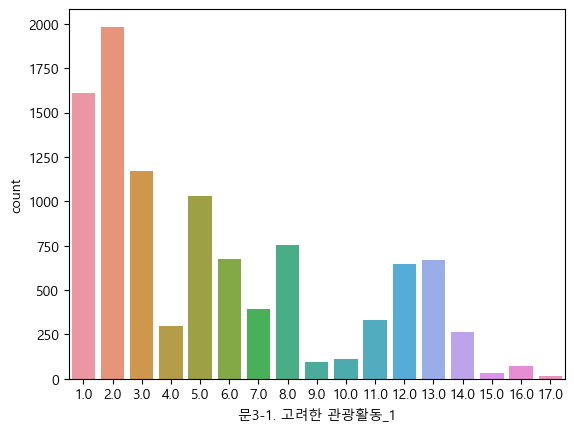

In [55]:
sns.countplot(x='문3-1. 고려한 관광활동_1',data=activity)

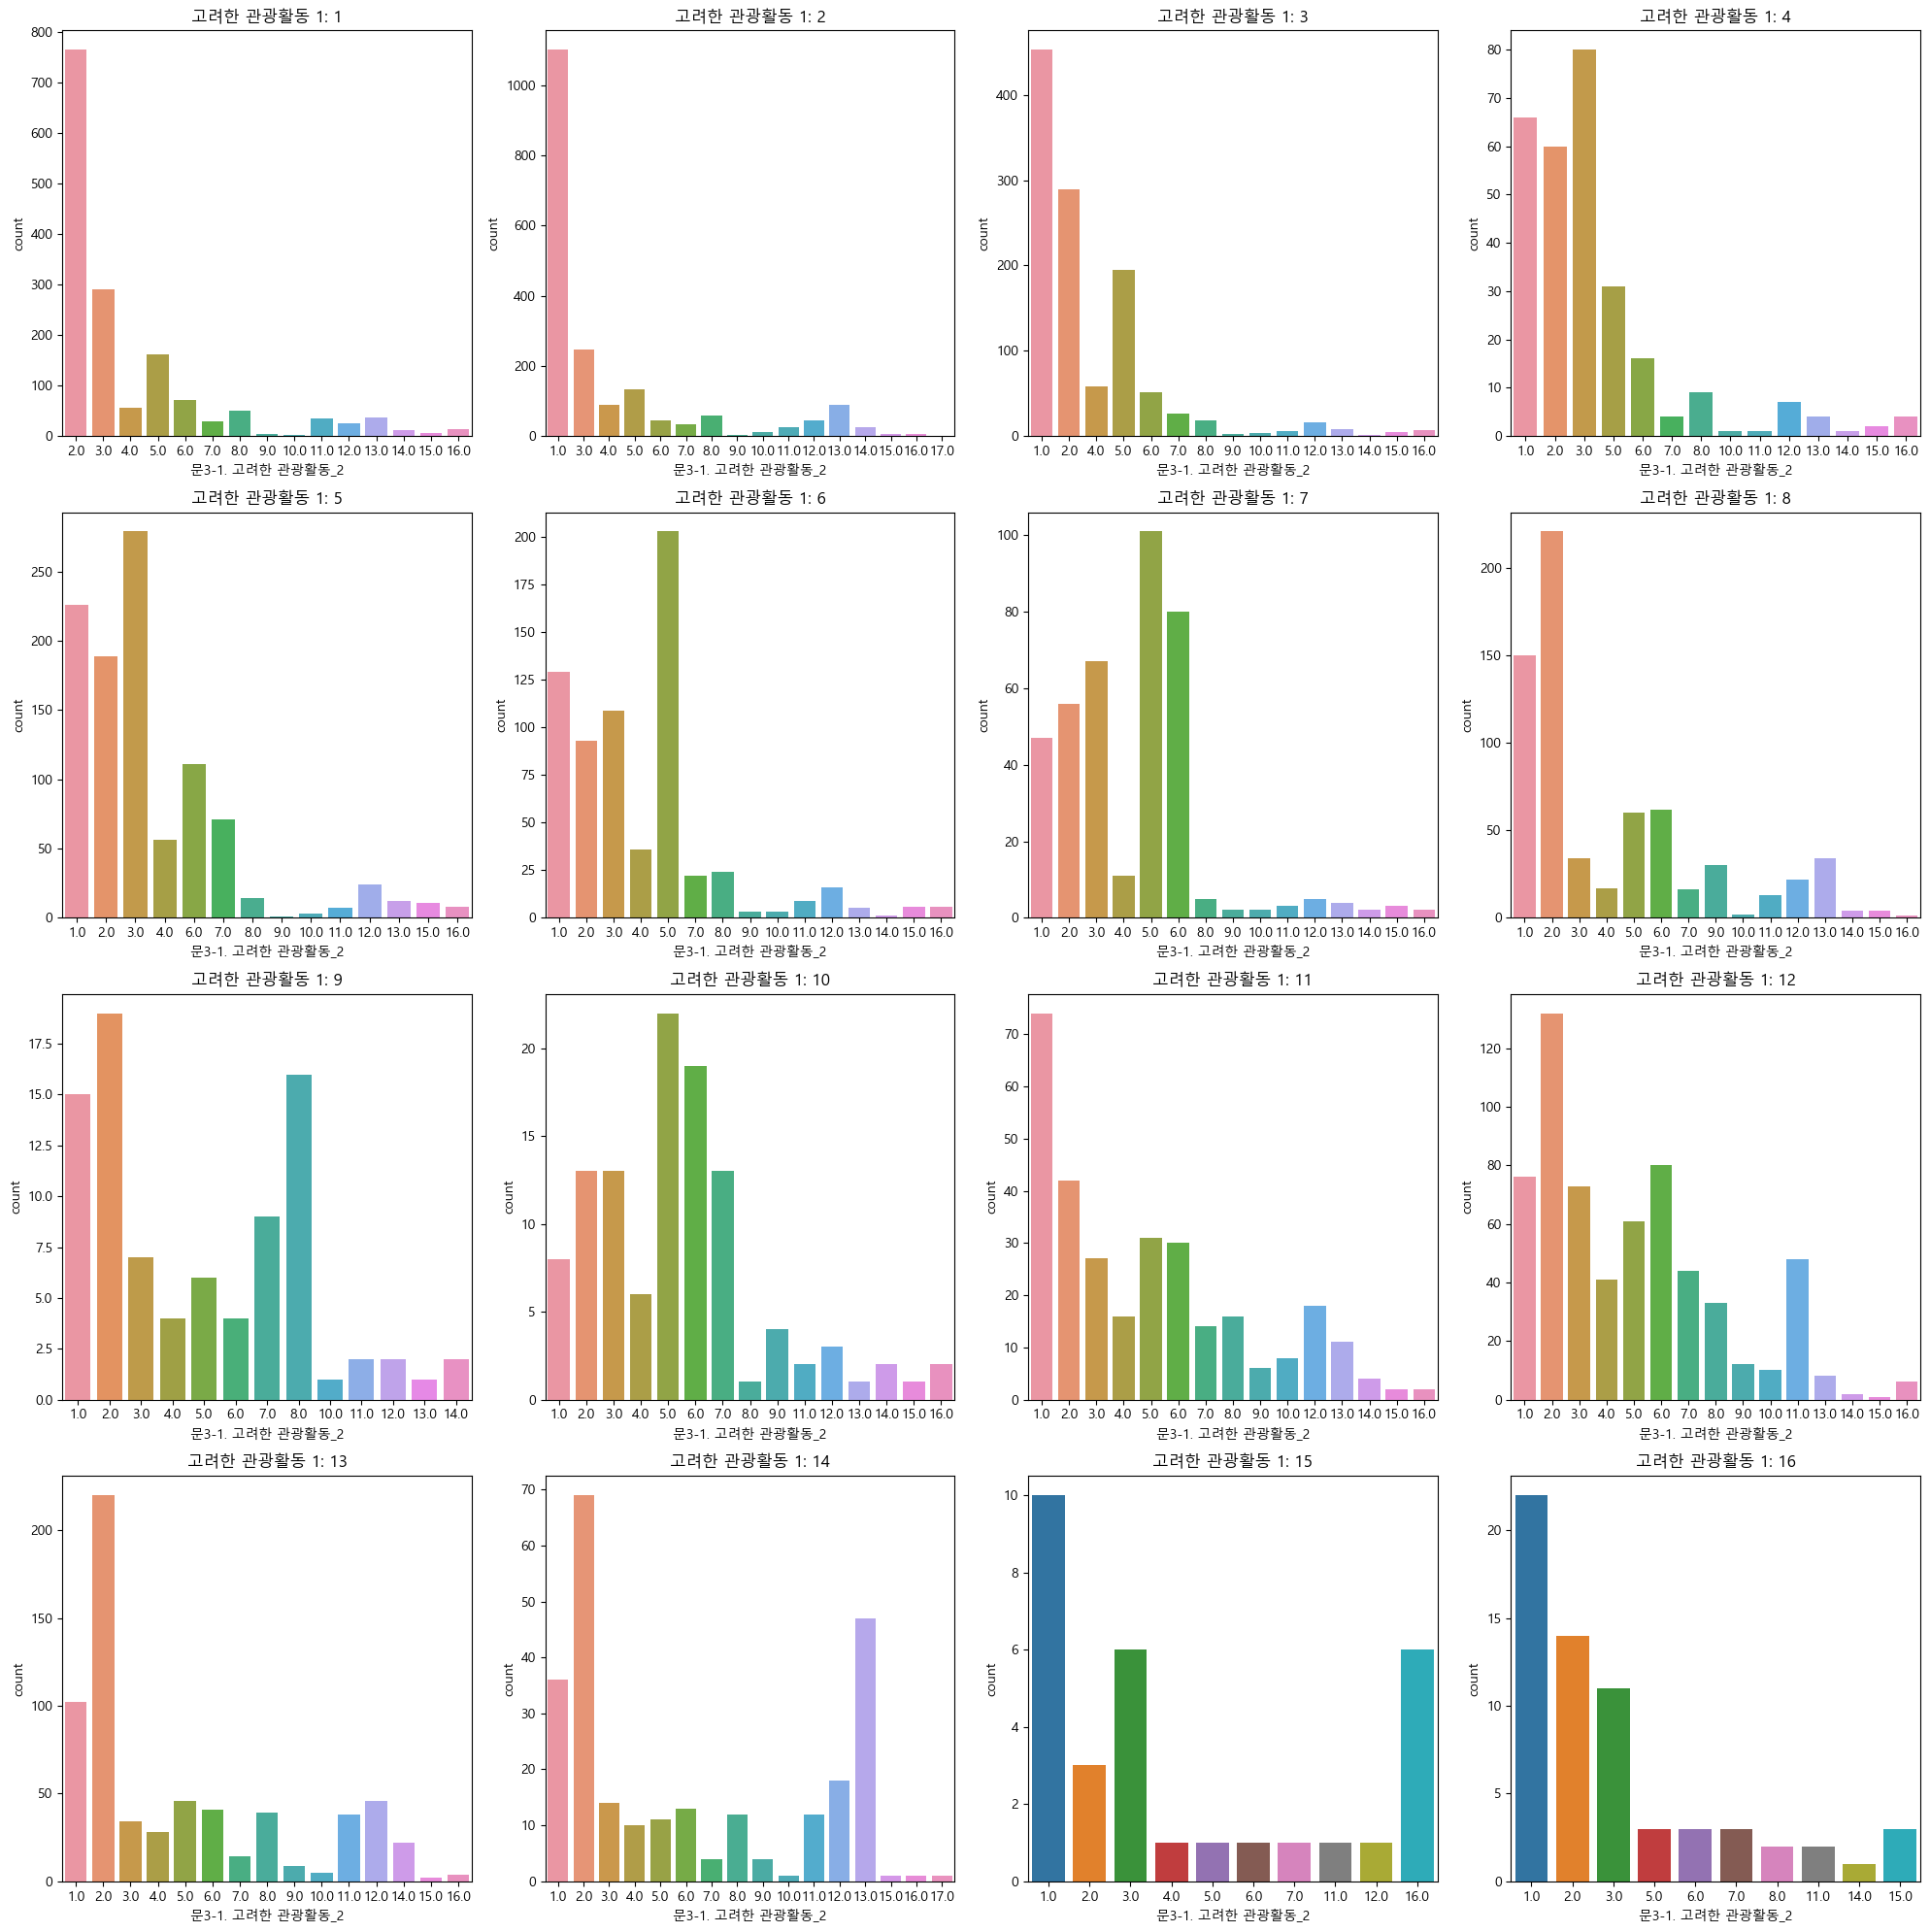

In [56]:
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
for i in range(16):
    sns.countplot(x='문3-1. 고려한 관광활동_2', data=activity[activity['문3-1. 고려한 관광활동_1']==float(i+1)], ax=ax[i//4,i%4])
    ax[i//4,i%4].set_title(f'고려한 관광활동 1: {i+1}')

plt.tight_layout()

In [57]:
activity['문3-1. 고려한 관광활동_1순위'] = activity['문3-1. 고려한 관광활동_1'].replace({
    1: '도시 소비형', 2: '도시 소비형',
    3: '역사, 전통, 자연', 4: '역사, 전통, 자연', 5: '역사, 전통, 자연', 6: '역사, 전통, 자연',
    7: '경험형', 8: '경험형', 9: '경험형', 11: '경험형', 14: '경험형', 15: '경험형',
    10: '특수 목적', 12: '특수 목적', 13: '특수 목적'
})

In [58]:
# activity.drop(columns=['문3-1. 고려한 관광활동_1','문3-1. 고려한 관광활동_2', '문3-1. 고려한 관광활동_3'], inplace=True)

In [59]:
activity['문3-1. 고려한 관광활동_1순위'].unique()

array(['도시 소비형', '경험형', '특수 목적', '역사, 전통, 자연', 16.0, 17.0], dtype=object)

In [60]:
# 16(기타)는 2순위 선택 결과에 따라 범주 포함시키자
# activity = pd.merge(left=activity, right=raw123, on='아이디', how='inner')

tmp = activity[activity['문3-1. 고려한 관광활동_1순위']==16.0]
tmp

,Unnamed: 0,아이디,국가별,성별,연령별,한국 방문횟수(카테고리),문1-1. 한국여행 관심 계기_1,문3-2. 고려한 관광인프라_1,여행동반자_그룹,방문 지역 수,"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)",문9-3. 총 체재기간_61일 이상 결측,여행 패턴,문3-1. 고려한 관광활동_1,문3-1. 고려한 관광활동_2,문3-1. 고려한 관광활동_3,문3-1. 고려한 관광활동_1순위
11,11,77,3,1,3,3,기타,2,가족형,1,271.320000,5.0,서울 단기형,16.0,2.0,3.0,16.0
14,14,80,3,1,2,1,콘텐츠 및 문화,5,가족형,2,432.820000,5.0,서울 단기형,16.0,2.0,5.0,16.0
15,15,81,3,2,3,1,경험형,3,가족형,2,432.820000,5.0,수도권/지방형(탐험가형),16.0,2.0,1.0,16.0
30,30,123,5,2,2,1,경험형,2,친구형,2,168.544350,6.0,서울 심층형,16.0,1.0,2.0,16.0
70,70,194,3,1,3,1,경험형,6,가족형,1,164.730000,5.0,서울 단기형,16.0,1.0,5.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9522,9522,17984,3,2,4,4,콘텐츠 및 문화,1,혼자형,1,262.868750,8.0,서울 심층형,16.0,11.0,9.0,16.0
9702,9702,18398,8,2,2,1,경험형,5,단체형,3,381.140000,5.0,서울 단기형,16.0,11.0,5.0,16.0
9745,9745,18513,5,2,4,4,경험형,2,친구형,1,293.714286,7.0,서울 심층형,16.0,2.0,NaN,16.0
9929,9929,18883,13,2,3,1,경험형,4,단체형,3,296.100000,5.0,서울 단기형,16.0,5.0,1.0,16.0


In [61]:
tmp[tmp['문3-1. 고려한 관광활동_2'].isna()]
# 2순위도 선택 안 한 row는 제거(6개)

,Unnamed: 0,아이디,국가별,성별,연령별,한국 방문횟수(카테고리),문1-1. 한국여행 관심 계기_1,문3-2. 고려한 관광인프라_1,여행동반자_그룹,방문 지역 수,"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)",문9-3. 총 체재기간_61일 이상 결측,여행 패턴,문3-1. 고려한 관광활동_1,문3-1. 고려한 관광활동_2,문3-1. 고려한 관광활동_3,문3-1. 고려한 관광활동_1순위
141,141,324,3,1,4,2,콘텐츠 및 문화,4,혼자형,2,247.633333,6.0,서울 심층형,16.0,NaN,NaN,16.0
226,226,507,5,2,2,4,가성비 및 접근성,5,친구형,2,319.750000,6.0,수도권/지방형(탐험가형),16.0,NaN,NaN,16.0
302,302,679,16,1,4,1,경험형,3,가족형,2,157.762500,12.0,수도권/지방형(탐험가형),16.0,NaN,NaN,16.0
577,577,1285,5,1,5,1,경험형,1,가족형,1,266.458333,4.0,서울 단기형,16.0,NaN,NaN,16.0
7211,7211,13686,5,2,2,4,기타,6,혼자형,1,256.600000,2.0,서울 단기형,16.0,NaN,NaN,16.0
8360,8360,15823,1,2,3,1,가성비 및 접근성,8,친구형,1,363.953333,3.0,수도권/지방형(탐험가형),16.0,NaN,NaN,16.0


In [62]:
drop_index = tmp[tmp['문3-1. 고려한 관광활동_2'].isna()].index
activity.drop(drop_index, inplace=True)

activity[activity['문3-1. 고려한 관광활동_1순위']==16.0]

,Unnamed: 0,아이디,국가별,성별,연령별,한국 방문횟수(카테고리),문1-1. 한국여행 관심 계기_1,문3-2. 고려한 관광인프라_1,여행동반자_그룹,방문 지역 수,"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)",문9-3. 총 체재기간_61일 이상 결측,여행 패턴,문3-1. 고려한 관광활동_1,문3-1. 고려한 관광활동_2,문3-1. 고려한 관광활동_3,문3-1. 고려한 관광활동_1순위
11,11,77,3,1,3,3,기타,2,가족형,1,271.320000,5.0,서울 단기형,16.0,2.0,3.0,16.0
14,14,80,3,1,2,1,콘텐츠 및 문화,5,가족형,2,432.820000,5.0,서울 단기형,16.0,2.0,5.0,16.0
15,15,81,3,2,3,1,경험형,3,가족형,2,432.820000,5.0,수도권/지방형(탐험가형),16.0,2.0,1.0,16.0
30,30,123,5,2,2,1,경험형,2,친구형,2,168.544350,6.0,서울 심층형,16.0,1.0,2.0,16.0
70,70,194,3,1,3,1,경험형,6,가족형,1,164.730000,5.0,서울 단기형,16.0,1.0,5.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9522,9522,17984,3,2,4,4,콘텐츠 및 문화,1,혼자형,1,262.868750,8.0,서울 심층형,16.0,11.0,9.0,16.0
9702,9702,18398,8,2,2,1,경험형,5,단체형,3,381.140000,5.0,서울 단기형,16.0,11.0,5.0,16.0
9745,9745,18513,5,2,4,4,경험형,2,친구형,1,293.714286,7.0,서울 심층형,16.0,2.0,NaN,16.0
9929,9929,18883,13,2,3,1,경험형,4,단체형,3,296.100000,5.0,서울 단기형,16.0,5.0,1.0,16.0


In [63]:
# 매핑 딕셔너리
activity_map = {
    1: '도시 소비형', 2: '도시 소비형',
    3: '역사, 전통, 자연', 4: '역사, 전통, 자연',
    5: '역사, 전통, 자연', 6: '역사, 전통, 자연',
    7: '경험형', 8: '경험형', 9: '경험형',
    11: '경험형', 14: '경험형', 15: '경험형',
    10: '특수 목적', 12: '특수 목적', 13: '특수 목적'
}

# 조건 마스크
mask = activity['문3-1. 고려한 관광활동_1순위'] == 16.0

# 조건에 해당하는 row만 치환
activity.loc[mask, '문3-1. 고려한 관광활동_1순위'] = (
    activity.loc[mask, '문3-1. 고려한 관광활동_2']
    .map(activity_map)
)


activity[activity['문3-1. 고려한 관광활동_1순위'] == 16.0]

,Unnamed: 0,아이디,국가별,성별,연령별,한국 방문횟수(카테고리),문1-1. 한국여행 관심 계기_1,문3-2. 고려한 관광인프라_1,여행동반자_그룹,방문 지역 수,"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)",문9-3. 총 체재기간_61일 이상 결측,여행 패턴,문3-1. 고려한 관광활동_1,문3-1. 고려한 관광활동_2,문3-1. 고려한 관광활동_3,문3-1. 고려한 관광활동_1순위


In [64]:
# 매핑 딕셔너리
activity_map = {
    1: '도시 소비형', 2: '도시 소비형',
    3: '역사, 전통, 자연', 4: '역사, 전통, 자연',
    5: '역사, 전통, 자연', 6: '역사, 전통, 자연',
    7: '경험형', 8: '경험형', 9: '경험형',
    11: '경험형', 14: '경험형', 15: '경험형',
    10: '특수 목적', 12: '특수 목적', 13: '특수 목적'
}

# 조건 마스크
mask = activity['문3-1. 고려한 관광활동_1순위'] == 17.0

# 조건에 해당하는 row만 치환
activity.loc[mask, '문3-1. 고려한 관광활동_1순위'] = (
    activity.loc[mask, '문3-1. 고려한 관광활동_2']
    .map(activity_map)
)


activity[activity['문3-1. 고려한 관광활동_1순위'] == 17.0]

,Unnamed: 0,아이디,국가별,성별,연령별,한국 방문횟수(카테고리),문1-1. 한국여행 관심 계기_1,문3-2. 고려한 관광인프라_1,여행동반자_그룹,방문 지역 수,"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)",문9-3. 총 체재기간_61일 이상 결측,여행 패턴,문3-1. 고려한 관광활동_1,문3-1. 고려한 관광활동_2,문3-1. 고려한 관광활동_3,문3-1. 고려한 관광활동_1순위


In [65]:
activity.columns

Index(['Unnamed: 0', '아이디', '국가별', '성별', '연령별', '한국 방문횟수(카테고리)',
       '문1-1. 한국여행 관심 계기_1', '문3-2. 고려한 관광인프라_1', '여행동반자_그룹', '방문 지역 수',
       '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)', '문9-3. 총 체재기간_61일 이상 결측',
       '여행 패턴', '문3-1. 고려한 관광활동_1', '문3-1. 고려한 관광활동_2', '문3-1. 고려한 관광활동_3',
       '문3-1. 고려한 관광활동_1순위'],
      dtype='object')

In [66]:
activity.drop(columns=['Unnamed: 0','문3-1. 고려한 관광활동_1', '문3-1. 고려한 관광활동_2', '문3-1. 고려한 관광활동_3'], inplace=True)
activity.columns

Index(['아이디', '국가별', '성별', '연령별', '한국 방문횟수(카테고리)', '문1-1. 한국여행 관심 계기_1',
       '문3-2. 고려한 관광인프라_1', '여행동반자_그룹', '방문 지역 수',
       '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)', '문9-3. 총 체재기간_61일 이상 결측',
       '여행 패턴', '문3-1. 고려한 관광활동_1순위'],
      dtype='object')

**고려한 관광인프라**

<Axes: xlabel='문3-2. 고려한 관광인프라_1', ylabel='count'>

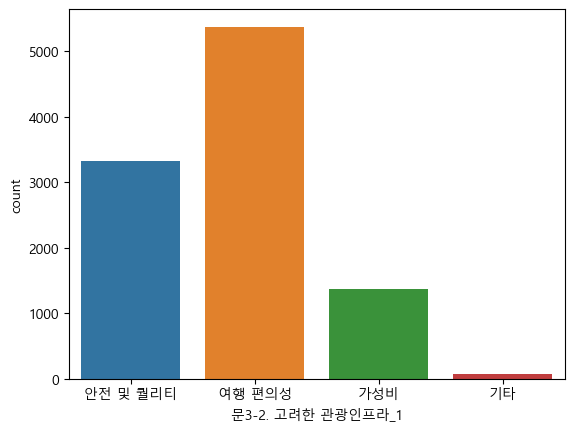

In [67]:
activity['문3-2. 고려한 관광인프라_1'] = activity['문3-2. 고려한 관광인프라_1'].replace({
    1 : '여행 편의성', 2 : '여행 편의성', 6 : '여행 편의성', 8 : '여행 편의성',
    3 : '안전 및 퀄리티', 5 : '안전 및 퀄리티', 7 : '안전 및 퀄리티',
    4 : '가성비',
    9: '기타'})


sns.countplot(x='문3-2. 고려한 관광인프라_1',data=activity)

In [68]:
activity.to_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_7차_전처리.csv', index=False)

## 7) 8차
- 성별 컬럼 제거
- ‘한국여행 관심계기’의 ‘기타’범주 전처리

In [71]:
df = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_7차_전처리.csv')

**성별 제거**

In [72]:
df.drop(columns=['성별'], inplace=True)

**한국여행 관심계기의 기타 범주 전처리**

In [73]:
raw = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_만족도조사.csv', encoding='cp949')

In [74]:
cols = ['아이디', '문1-1. 한국여행 관심 계기_2']

df1 = pd.merge(left=df, right=raw[cols], on='아이디', how='inner')
# df1.drop(columns='문1-1. 한국여행 관심 계기_1', inplace=True)
df1.columns

Index(['아이디', '국가별', '연령별', '한국 방문횟수(카테고리)', '문1-1. 한국여행 관심 계기_1',
       '문3-2. 고려한 관광인프라_1', '여행동반자_그룹', '방문 지역 수',
       '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)', '문9-3. 총 체재기간_61일 이상 결측',
       '여행 패턴', '문3-1. 고려한 관광활동_1순위', '문1-1. 한국여행 관심 계기_2'],
      dtype='object')

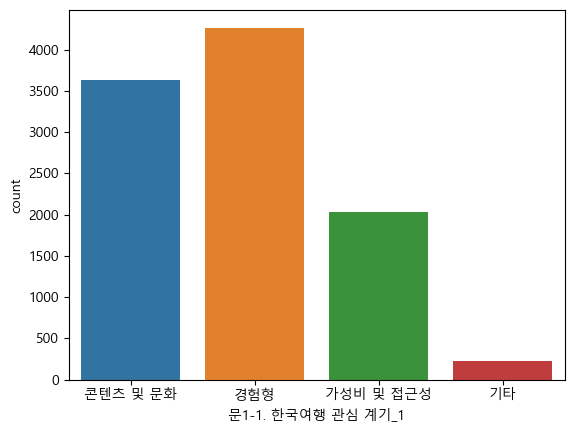

In [75]:
sns.countplot(data=df1, x='문1-1. 한국여행 관심 계기_1')
plt.show()

# df1[df1['문1-1. 한국여행 관심 계기_1순위']==11]

여기부터 코드가 꼬인것같은데 뭔지 모르겠음..

In [165]:
mask = (
    (df1['문1-1. 한국여행 관심 계기_1'] == 11) &
    (df1['문1-1. 한국여행 관심 계기_2'].isna())
)

df2 = df1.loc[~mask].reset_index(drop=True)

In [166]:
# fig, ax = plt.subplots(5, 2, figsize=(15, 12))
# for i in range(10):
#     sns.countplot(x='문1-1. 한국여행 관심 계기_2', data=df2[df2['문1-1. 한국여행 관심 계기_1']==float(i+1)], ax=ax[i//2,i%2])
#     ax[i//2,i%2].set_title(f'한국여행 관심 계기_1: {i+1}')

# plt.tight_layout()

In [167]:
df2['문1-1. 한국여행 관심 계기_1순위'] = df2['문1-1. 한국여행 관심 계기_1'].replace({
    1: '경험 및 관계', 2: '경험 및 관계', 3: '경험 및 관계',
    4: '가성비 및 접근성', 5: '가성비 및 접근성', 6: '가성비 및 접근성', 10: '가성비 및 접근성',
    7: 'K-컬처형', 8: 'K-컬처형', 9: 'K-컬처형'
})

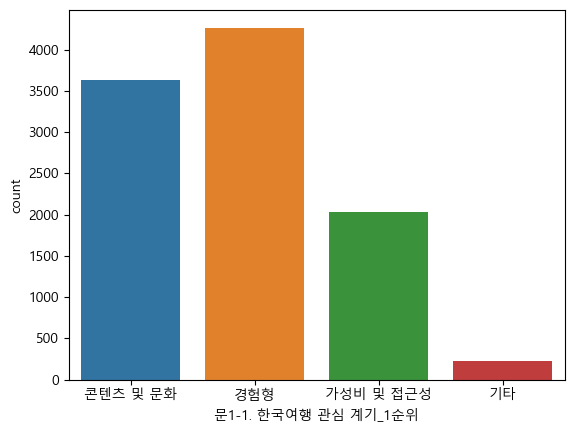

In [168]:
sns.countplot(x = '문1-1. 한국여행 관심 계기_1순위', data=df2)
plt.show()

In [175]:
col1 = '문1-1. 한국여행 관심 계기_1순위'   # 이미 문자형
col2 = '문1-1. 한국여행 관심 계기_2'      # 숫자형

mask = (df2[col1] == '기타') & (df2[col2].notna())

df2.loc[mask, col1] = df2.loc[mask, col2].map(reason_map)

In [173]:
# reason_map = {
#     1: '경험 및 관계', 2: '경험 및 관계', 3: '경험 및 관계',
#     4: '가성비 및 접근성', 5: '가성비 및 접근성', 6: '가성비 및 접근성', 10: '가성비 및 접근성',
#     7: 'K-컬처형', 8: 'K-컬처형', 9: 'K-컬처형'
# }

# mask = df2[df2['문1-1. 한국여행 관심 계기_1순위'] == 11]

# df2.loc[mask, '문1-1. 한국여행 관심 계기_1순위'] = df2.loc[mask, '문1-1. 한국여행 관심 계기_2'].map(reason_map)

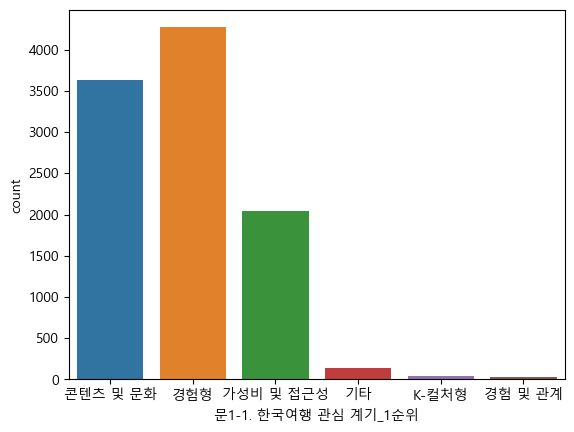

In [176]:
sns.countplot(x = '문1-1. 한국여행 관심 계기_1순위', data=df2)
plt.show()

In [157]:
df2.drop(columns='문1-1. 한국여행 관심 계기_2', inplace=True)
df2.columns

Index(['아이디', '국가별', '연령별', '한국 방문횟수(카테고리)', '문1-1. 한국여행 관심 계기_1',
       '문3-2. 고려한 관광인프라_1', '여행동반자_그룹', '방문 지역 수',
       '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)', '문9-3. 총 체재기간_61일 이상 결측',
       '여행 패턴', '문3-1. 고려한 관광활동_1순위', '문1-1. 한국여행 관심 계기_1순위'],
      dtype='object')

In [ ]:
df2.to_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_8차_전처리.csv', index=False)

## 8) 9차
- 한국방문횟수 - 첫방문 / 재방문
- new_여행패턴 : 방문지역수 + 방문지역
- 사후 eda를 위한 변수 추가
- 상관성 보기

In [ ]:
df = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_8차_전처리.csv', encoding = 'utf-8')

**한국 방문횟수**

In [ ]:
df['한국 방문횟수(카테고리)'] = df['한국 방문횟수(카테고리)'].map(
lambda x: '첫방문' if x == 1 else '재방문'
)
df['한국 방문횟수(카테고리)'].value_counts()

**new_여행패턴**

In [ ]:
vr1 = df[df['방문 지역 수'] == 1]
vr2 = df[df['방문 지역 수'] != 1]
# 1인 경우가 6639
# 1이 아닌 경우가 3364

In [ ]:
visit_cols = [col for col in df.columns if col.startswith('문9-2. 방문지역_')]
# 방문지역_1 : 서울
# 방문지역_2 : 경기
# 방문지역_3 : 인천
# 방문지역_13 : 부산
# 방문지역_17 : 제주도

vr1

In [ ]:
import pandas as pd

seoul_col = '문9-2. 방문지역_1'
capital_cols = ['문9-2. 방문지역_2', '문9-2. 방문지역_3']

local_cols = [
    col for col in vr1.columns
    if col.startswith('문9-2. 방문지역_')
    and col not in [seoul_col] + capital_cols
]

def classify_single_region(row):
    if pd.notna(row[seoul_col]):
        return '서울 집중형'

    elif row[capital_cols].notna().any():
        return '탐험형'

    elif row[local_cols].notna().any():
        return '탐험형'

    else:
        return None

vr1['new_여행패턴'] = vr1.apply(classify_single_region, axis=1)
vr1['new_여행패턴'].value_counts(dropna=False)

vr2

In [ ]:
import pandas as pd

seoul_col = '문9-2. 방문지역_1'
capital_cols = ['문9-2. 방문지역_2', '문9-2. 방문지역_3']

local_cols = [
    col for col in vr2.columns
    if col.startswith('문9-2. 방문지역_')
    and col not in [seoul_col] + capital_cols
]

def classify_multi_region(row):
    has_seoul = pd.notna(row[seoul_col])
    has_capital = row[capital_cols].notna().any()
    has_local = row[local_cols].notna().any()

    # 서울 + 수도권
    if has_seoul and has_capital:
        return '서울 확산형'

    # 서울 + 지방
    elif has_seoul and has_local:
        return '서울 확산형'

    # 서울 제외 (지방만)
    elif not has_seoul and has_local:
        return '탐험형'

    else:
        return None

vr2['new_여행패턴'] = vr2.apply(classify_multi_region, axis=1)
vr2['new_여행패턴'].value_counts(dropna=False)

In [ ]:
vr2[vr2['new_여행패턴'].isna()]
vr2.loc[
    vr2['new_여행패턴'].isna(),
    ['방문 지역 수', seoul_col] + capital_cols + local_cols
]
# 방문지역수 컬럼이 이상함 + 수도권만 방문 케이스

In [ ]:
# new_여행패턴이 NaN인 행만 추출
mask = vr2['new_여행패턴'].isna()

# 서울만 체크된 경우 → 서울 단독형
vr2.loc[
    mask & vr2[seoul_col].notna(),
    'new_여행패턴'
] = '서울 집중형'

# 수도권(2,3)만 체크된 경우 → 수도권 집중형
vr2.loc[
    mask & vr2[capital_cols].notna().any(axis=1),
    'new_여행패턴'
] = '탐험형'

vr2['new_여행패턴'].value_counts(dropna=False)

In [ ]:
df = df.copy()
df['new_여행패턴'] = None

df.loc[vr1.index, 'new_여행패턴'] = vr1['new_여행패턴']
df.loc[vr2.index, 'new_여행패턴'] = vr2['new_여행패턴']

df['new_여행패턴'].value_counts()

In [ ]:
import matplotlib.pyplot as plt

counts = df['new_여행패턴'].value_counts()

plt.figure(figsize=(8, 5))
counts.plot(kind='bar')
plt.title('여행 패턴 분포')
plt.xlabel('여행 패턴')
plt.ylabel('빈도')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

countss = df['여행 패턴'].value_counts()
print(countss)

**사후 eda를 위한 변수추가**

In [ ]:
df2 = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_만족도조사.csv', encoding = 'cp949')

# 2) 결합 키
key = '아이디'

# 3) df2에서 "특정 말로 시작하는 컬럼" 자동 수집 + 고정 컬럼(국가별/성별/월별)
starts_with_targets = [
    '문10-2. 쇼핑 항목_',   # 이 말로 시작해야함
    '문10. 1인 지출경비(상하위 1% 대체)',
    '문9-2. 방문지역',    # 이 말로 시작해야함
    '문9-1. 가장 좋았던곳', # 이 말로 시작해야함
    '문8-1. 만족한 활동',  # 이 말로 시작해야함
    '문8. 참여한 활동'     # 이 말로 시작해야함
]

# startswith로 매칭되는 컬럼들 전부 가져오기
matched_cols = []
for prefix in starts_with_targets:
    matched_cols += [c for c in df2.columns if c.startswith(prefix)]

# 기본으로 꼭 붙일 컬럼들
base_cols = [key, '국가별', '성별', '월별']

# 최종 추가 컬럼(중복 제거 + 실제 존재하는 것만)
cols_to_add = []
for c in base_cols + matched_cols:
    if c in df2.columns and c not in cols_to_add:
        cols_to_add.append(c)

# 4) id 중복 방지 후 merge
df2_sub = df2[cols_to_add].drop_duplicates(subset=[key])
df = df.merge(df2_sub, on=key, how='left')

# (선택) 결과 확인
print("추가된 컬럼 수:", len(cols_to_add) - 1)  # id 제외
print("df shape:", df.shape)
print("df2_sub shape:", df2_sub.shape)

df.to_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_9차_전처리.csv', encoding = 'utf-8')

#### 상관성

In [79]:
df= pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/데이터/2024_9차_전처리.csv', encoding = 'utf-8')

In [80]:
num_cols = ['방문 지역 수', '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)',
       '문9-3. 총 체재기간_61일 이상 결측', '월별' , '문10. 1인 지출경비(상하위 1% 대체)']

cat_cols = ['연령별', '한국 방문횟수(카테고리)', '문3-2. 고려한 관광인프라_1',
       '여행동반자_그룹', '여행 패턴', '문3-1. 고려한 관광활동_1순위', '문1-1. 한국여행 관심 계기_1순위',
       '국가별', '성별', 'new_여행패턴']

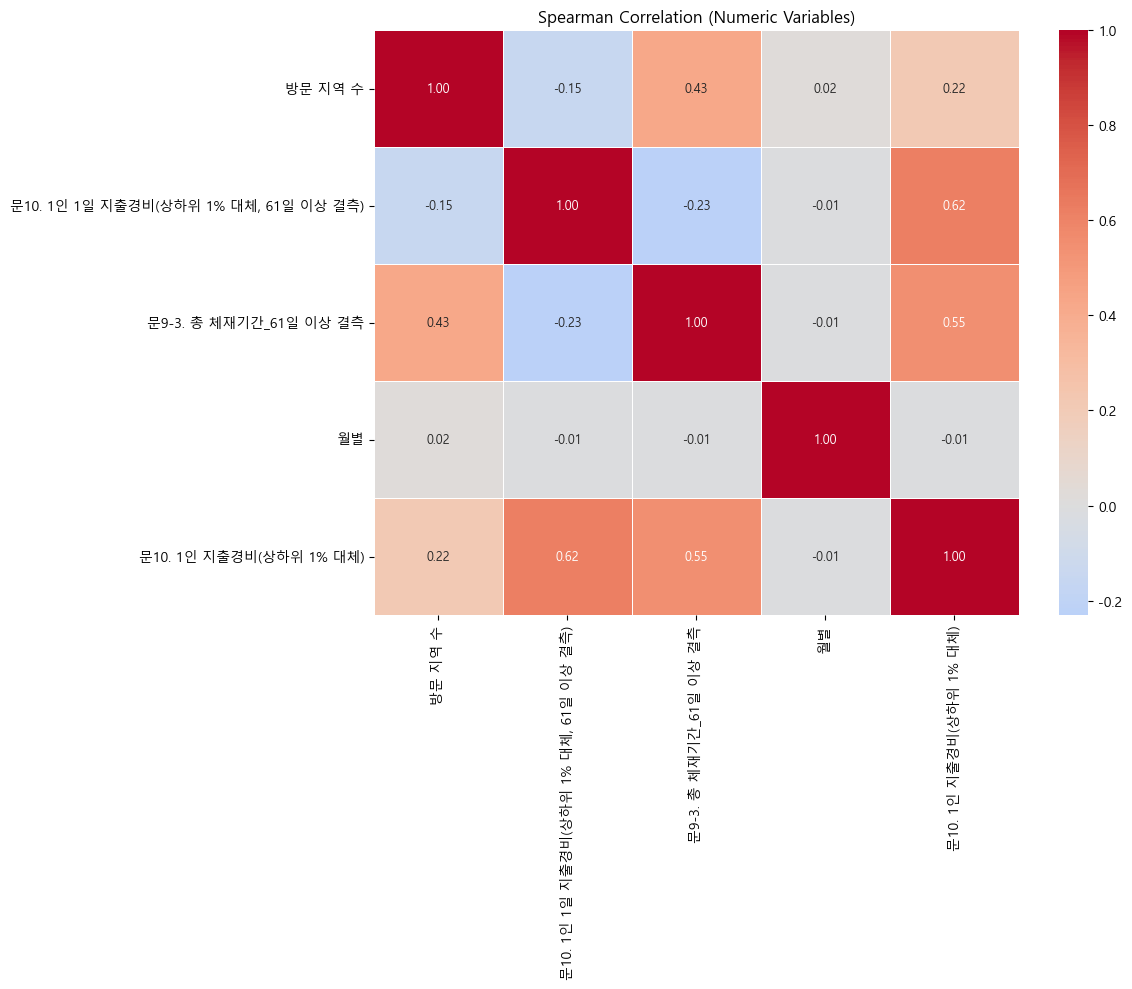

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_num = df[num_cols].corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_num,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot=True,          # ⭐ 숫자 표시
    fmt='.2f',           # ⭐ 소수점 둘째 자리
    annot_kws={'size':9} # ⭐ 글자 크기 (선택)
)
plt.title('Spearman Correlation (Numeric Variables)')
plt.tight_layout()
plt.show()


In [82]:
# 2. 범주형 - 크래마

## 해석 기준
# 0 ~ 0.1: 거의 없음
# 0.1 ~ 0.3: 약함
# 0.3 ~ 0.5: 중간
# 0.5+: 강함

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cramer_mat = pd.DataFrame(index=cat_cols, columns=cat_cols)

for c1 in cat_cols:
    for c2 in cat_cols:
        cramer_mat.loc[c1, c2] = cramers_v(df[c1], df[c2])

cramer_mat

,연령별,한국 방문횟수(카테고리),문3-2. 고려한 관광인프라_1,여행동반자_그룹,여행 패턴,문3-1. 고려한 관광활동_1순위,문1-1. 한국여행 관심 계기_1순위,국가별,성별,new_여행패턴
연령별,1.0,0.133016,0.055726,0.141772,0.09141,0.085598,0.076912,0.117716,0.059942,0.067084
한국 방문횟수(카테고리),0.133016,0.999797,0.054973,0.138517,0.167623,0.188067,0.133523,0.386303,0.133344,0.182373
문3-2. 고려한 관광인프라_1,0.055726,0.054973,1.0,0.078018,0.102839,0.053359,0.046317,0.203582,0.017838,0.066582
여행동반자_그룹,0.141772,0.138517,0.078018,1.0,0.165371,0.130332,0.102505,0.224061,0.162729,0.187532
여행 패턴,0.09141,0.167623,0.102839,0.165371,1.0,0.168164,0.184383,0.451451,0.050076,0.663717
문3-1. 고려한 관광활동_1순위,0.085598,0.188067,0.053359,0.130332,0.168164,1.0,0.118163,0.193865,0.094904,0.181802
문1-1. 한국여행 관심 계기_1순위,0.076912,0.133523,0.046317,0.102505,0.184383,0.118163,1.0,0.315221,0.121564,0.175118
국가별,0.117716,0.386303,0.203582,0.224061,0.451451,0.193865,0.315221,1.0,0.146094,0.357798
성별,0.059942,0.133344,0.017838,0.162729,0.050076,0.094904,0.121564,0.146094,0.999773,0.071671
new_여행패턴,0.067084,0.182373,0.066582,0.187532,0.663717,0.181802,0.175118,0.357798,0.071671,1.0


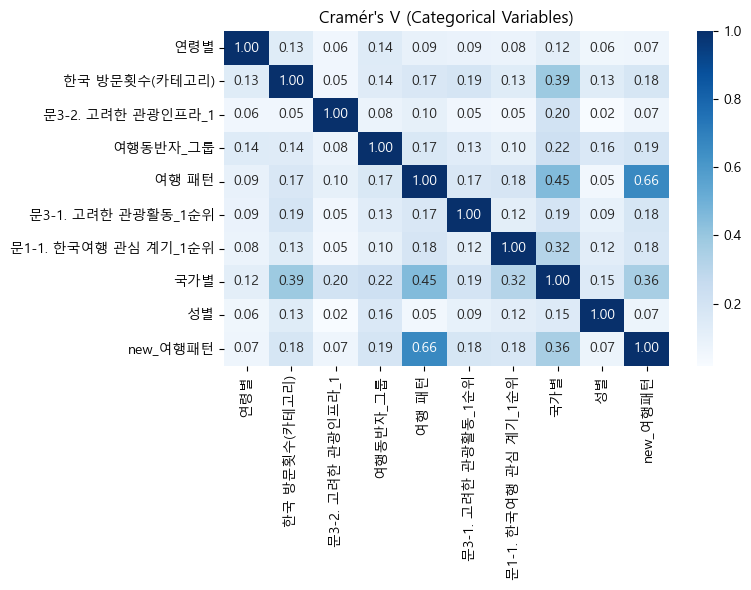

In [83]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cramer_mat = pd.DataFrame(index=cat_cols, columns=cat_cols)

for c1 in cat_cols:
    for c2 in cat_cols:
        cramer_mat.loc[c1, c2] = cramers_v(df[c1], df[c2])

cramer_mat = cramer_mat.astype(float)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cramer_mat,
    cmap='Blues',
    annot=True,
    fmt='.2f'
)
plt.title("Cramér's V (Categorical Variables)")
plt.tight_layout()
plt.show()

## 해석 기준
# 0 ~ 0.1: 거의 없음
# 0.1 ~ 0.3: 약함
# 0.3 ~ 0.5: 중간
# 0.5+: 강함

In [84]:
## 3. 수치형 - 범주형
def eta_squared(y, x):
    groups = df.groupby(x)[y]
    overall_mean = df[y].mean()
    ss_between = sum(len(g) * (g.mean() - overall_mean)**2 for _, g in groups)
    ss_total = sum((df[y] - overall_mean)**2)
    return ss_between / ss_total

eta_df = pd.DataFrame(index=num_cols, columns=cat_cols)

for num in num_cols:
    for cat in cat_cols:
        eta_df.loc[num, cat] = eta_squared(num, cat)

eta_df = eta_df.astype(float)


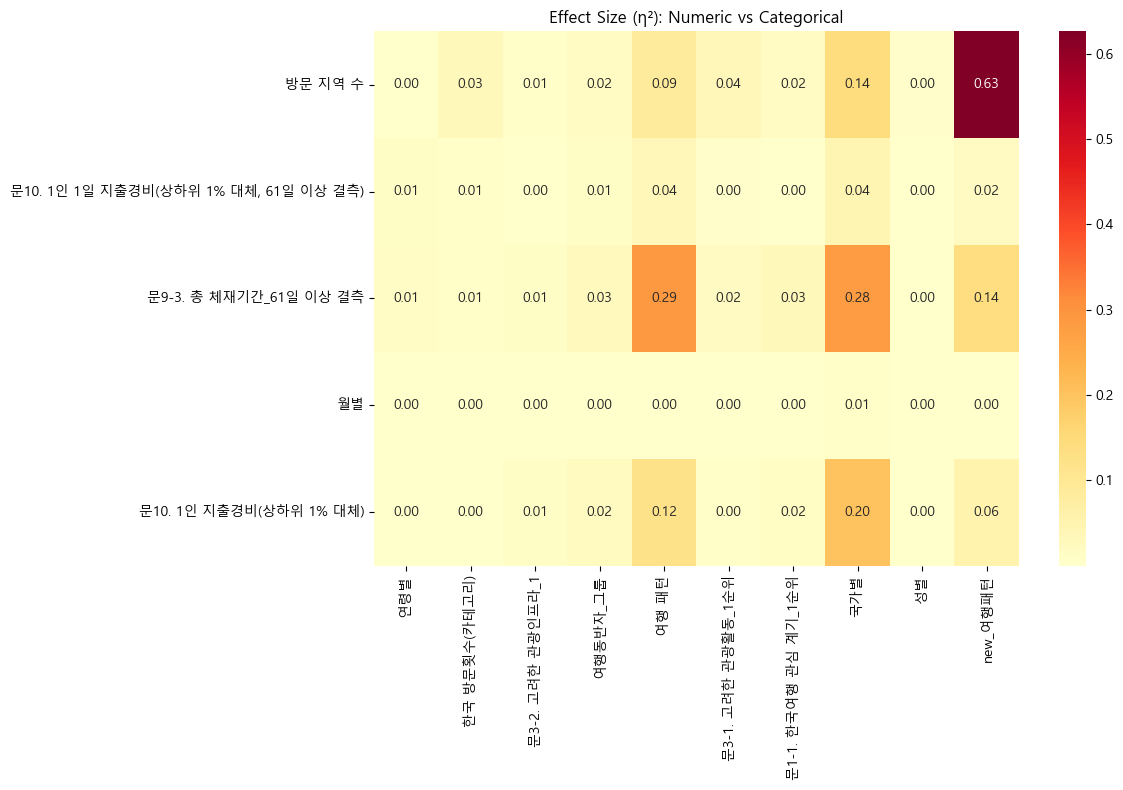

In [85]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    eta_df,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f'
)
plt.title('Effect Size (η²): Numeric vs Categorical')
plt.tight_layout()
plt.show()


# η² < 0.01 : 거의 영향 없음

# η² ≈ 0.06 : 중간

# η² ≥ 0.14 : 큼

# 2. 모델링


In [89]:
import pandas as pd
import warnings
import re
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import numpy as np
import seaborn as sns
import gower
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# warning 없애기
warnings.filterwarnings("ignore")

# 글씨체 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


df = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/데이터/2024_9차_전처리.csv', encoding = 'utf-8')

In [90]:
# new_여행패턴과 상관관계가 높은 총 체재기간 변수 제외한 모델링

# 분석에 불필요한 고유 ID 제거
cluster_data = df[['연령별', '한국 방문횟수(카테고리)', '문3-2. 고려한 관광인프라_1', '여행동반자_그룹',
                   '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)',
                   '문3-1. 고려한 관광활동_1순위', '문1-1. 한국여행 관심 계기_1순위', 'new_여행패턴']]

# [중요] '숫자'로 코딩된 '범주형' 변수를 문자열로 변환
# Gower 라이브러리가 이를 인식하고 매칭(0 or 1) 방식으로 거리를 계산하게 하기 위함
cluster_data['연령별'] = cluster_data['연령별'].astype('object')

print("< 분석 대상 변수 타입 확인 >")
print(cluster_data.dtypes)
print("-" * 50)
print(cluster_data.shape)

< 분석 대상 변수 타입 확인 >
연령별                                       object
한국 방문횟수(카테고리)                             object
문3-2. 고려한 관광인프라_1                         object
여행동반자_그룹                                  object
문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)    float64
문3-1. 고려한 관광활동_1순위                        object
문1-1. 한국여행 관심 계기_1순위                      object
new_여행패턴                                  object
dtype: object
--------------------------------------------------
(10003, 8)


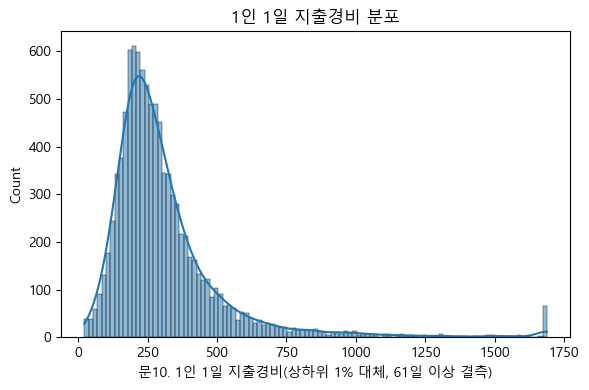

In [91]:
num_cols = ['문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)']

plt.figure(figsize=(6, 4))
sns.histplot(data=df, x=num_cols[0], kde=True)
plt.title('1인 1일 지출경비 분포')
plt.tight_layout()
plt.show()


로그 변환 완료. 지출경비와 체재기간의 분포가 압축되었습니다.
1. Gower 거리 행렬 계산 시작... (약 1만 건, 1~3분 소요 예상)
   -> 계산 완료. 행렬 크기: (10003, 10003)
   -> 메모리 점유율(약): 381.70 MB
2. 계층적 군집화(Linkage) 수행 중...
   -> Linkage 완료.


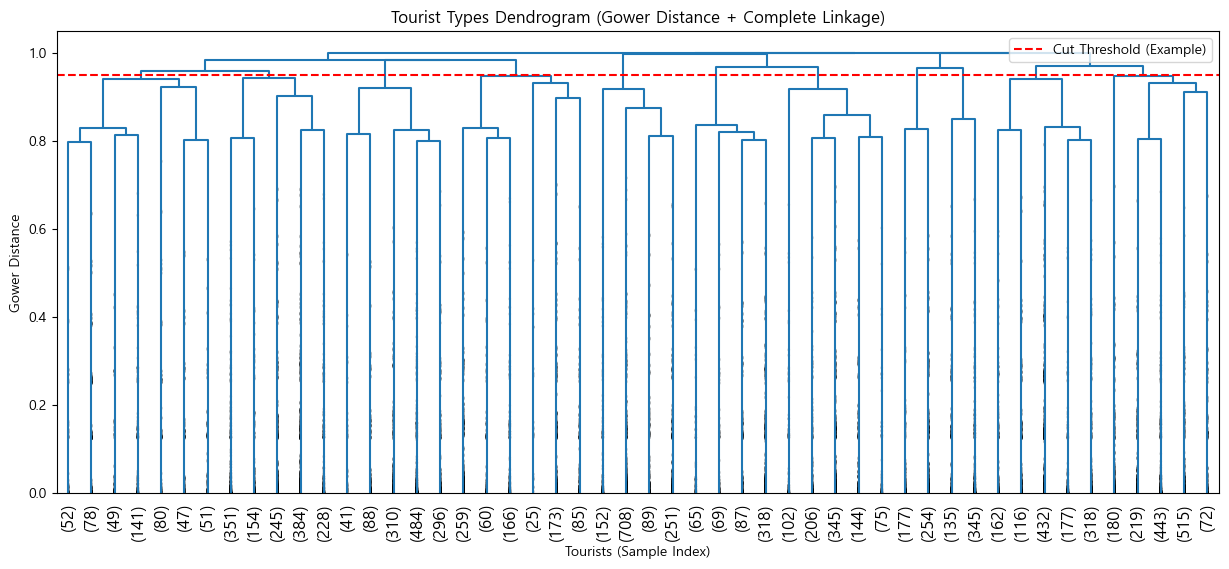

In [92]:
# 1. 로그 변환할 변수 (분포가 치우친 연속형 변수)
cols_to_log = [
    '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'
]

# 2. 변환 적용 (log1p 사용: log(x+1)로 0값 에러 방지)
# 원본 데이터 보호를 위해 copy() 사용 권장
cluster_data_transformed = cluster_data.copy()

for col in cols_to_log:
    cluster_data_transformed[col] = np.log1p(cluster_data_transformed[col].astype(float))

# 3. 로그 변환 안 하는 변수들 (연령별, 방문횟수)은
#    이미 int 형태로 되어 있는지(str 아님)만 확인하고 그대로 둡니다.

print("로그 변환 완료. 지출경비와 체재기간의 분포가 압축되었습니다.")

print("1. Gower 거리 행렬 계산 시작... (약 1만 건, 1~3분 소요 예상)")

# gower_matrix 함수는 컬럼 타입을 보고 자동으로 거리 계산 방식을 결정합니다.
# object/str -> Dice (같으면 0, 다르면 1)
# int/float -> Manhattan (Range로 정규화)
dist_matrix = gower.gower_matrix(cluster_data_transformed)

print(f"   -> 계산 완료. 행렬 크기: {dist_matrix.shape}")
print(f"   -> 메모리 점유율(약): {dist_matrix.nbytes / 1024 / 1024:.2f} MB")

print("2. 계층적 군집화(Linkage) 수행 중...")

# 거리 행렬을 압축된 형태(condensed form)로 변환
condensed_dist = squareform(dist_matrix)

# Linkage 수행
# method='complete': Gower 거리 사용 시 'Complete'(최장거리법) 또는 'Average'(평균거리법) 추천
# 'ward'는 유클리드 거리 기반이라 논리적으로 맞지 않음
Z = linkage(condensed_dist, method='complete')

print("   -> Linkage 완료.")

# 메모리 확보를 위해 거리 행렬 삭제 (선택 사항)
del dist_matrix, condensed_dist


plt.figure(figsize=(15, 6))
plt.title("Tourist Types Dendrogram (Gower Distance + Complete Linkage)")
plt.xlabel("Tourists (Sample Index)")
plt.ylabel("Gower Distance")

# 1만 개를 다 그리면 안 보이므로 상위 50개만 요약해서 시각화
dendrogram(
    Z,
    truncate_mode='lastp',
    p=50,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.axhline(y=0.95, color='r', linestyle='--', label='Cut Threshold (Example)')
plt.legend()
plt.show()

In [94]:
# [사용자 설정] 덴드로그램을 보고 결정한 군집 수 (예: 4개)
k_final = 11

# 군집 라벨 생성
labels = fcluster(Z, k_final, criterion='maxclust')
df['Cluster'] = labels # 원본 데이터프레임에 할당

# 군집별 특성 요약 (Profiling)
def get_mode(x):
    return x.mode()[0] if not x.mode().empty else np.nan

# 분석할 변수들을 수치형과 범주형으로 나눠서 요약
agg_dict = {

    '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)': 'mean',

    # 나머지 범주형 변수들은 최빈값(Mode) 확인

    '연령별': get_mode,
    '한국 방문횟수(카테고리)': get_mode,
    '문1-1. 한국여행 관심 계기_1순위': get_mode,
    '문3-2. 고려한 관광인프라_1': get_mode,
    '여행동반자_그룹': get_mode,
    '문3-1. 고려한 관광활동_1순위': get_mode,
    'new_여행패턴': get_mode
}

# 그룹별 요약 테이블 생성
summary_df = df.groupby('Cluster').agg(agg_dict)
summary_df['Count'] = df['Cluster'].value_counts() # 인원 수 추가

print(f"\n< 군집별 특성 요약 (k={k_final}) >")
# 보기 좋게 전치(Transpose)하여 출력
display(summary_df.T)


#'연령별', '한국 방문횟수(카테고리)', '문3-2. 고려한 관광인프라_1', '여행동반자_그룹',
 #                  '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)',
  #                 '문3-1. 고려한 관광활동_1순위', '문1-1. 한국여행 관심 계기_1순위', 'new_여행패턴'


< 군집별 특성 요약 (k=11) >


Cluster,1,2,3,4,5,6,7,8,9,10,11
"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)",269.524405,354.987204,331.286681,286.680656,288.903481,313.699801,332.952729,356.57991,397.644262,282.087346,296.674295
연령별,3,3,2,2,2,2,3,5,2,2,2
한국 방문횟수(카테고리),재방문,재방문,재방문,재방문,첫방문,첫방문,첫방문,재방문,재방문,첫방문,첫방문
문1-1. 한국여행 관심 계기_1순위,경험 및 관계,경험 및 관계,K-컬처형,경험 및 관계,경험 및 관계,K-컬처형,경험 및 관계,경험 및 관계,가성비 및 접근성,가성비 및 접근성,K-컬처형
문3-2. 고려한 관광인프라_1,여행 편의성,안전 및 퀄리티,여행 편의성,여행 편의성,여행 편의성,안전 및 퀄리티,안전 및 퀄리티,여행 편의성,여행 편의성,여행 편의성,여행 편의성
여행동반자_그룹,혼자형,가족형,친구형,가족형,가족형,가족형,가족형,가족형,친구형,친구형,가족형
문3-1. 고려한 관광활동_1순위,"역사, 전통, 자연",도시 소비형,도시 소비형,도시 소비형,도시 소비형,도시 소비형,"역사, 전통, 자연","역사, 전통, 자연",도시 소비형,도시 소비형,"역사, 전통, 자연"
new_여행패턴,탐험형,서울 집중형,서울 집중형,서울 확산형,서울 확산형,서울 집중형,서울 집중형,서울 집중형,서울 집중형,서울 집중형,서울 집중형
Count,498,1362,1219,768,1200,539,872,431,480,1205,1429


In [95]:
df.to_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_31.csv', encoding = 'utf-8')

# 3. 사후 EDA

In [96]:
df = pd.read_csv('C:/Users/wndus/OneDrive/바탕 화면/관광지추천/data/2024_31.csv', encoding = 'utf-8')

In [97]:
import plotly.express as px

def plot_sunburst(df, target_col):
    # df: 클러스터 결과가 포함된 원본 데이터프레임
    fig = px.sunburst(df,
                      path=['Cluster', target_col],
                      values='방문 지역 수',
                      color='Cluster',
                      title=f"군집별 {target_col} 구성 비중")

    # 텍스트 표시 설정: 라벨(이름)과 해당 항목의 비중(percent entry) 표시
    # 'percent parent'는 바로 위 부모 대비 비율, 'percent entry'는 현재 레벨에서의 비율입니다.
    fig.update_traces(textinfo='label+percent entry')

    fig.show()

# 실행 예시는 기존과 동일합니다.
# plot_sunburst(df, '문3-1. 고려한 관광활동_1순위')

# 예: 군집별 관광활동 선호도 확인
plot_sunburst(df, '문3-1. 고려한 관광활동_1순위')
plot_sunburst(df, '문3-2. 고려한 관광인프라_1')
plot_sunburst(df, '문1-1. 한국여행 관심 계기_1순위')
plot_sunburst(df, 'new_여행패턴')
plot_sunburst(df, '여행동반자_그룹')
plot_sunburst(df, '연령별')
plot_sunburst(df, '국가별')
plot_sunburst(df, '월별')
plot_sunburst(df, '한국 방문횟수(카테고리)')
plot_sunburst(df, '성별')


# '연령별', '한국 방문횟수(카테고리)', '문3-2. 고려한 관광인프라_1', '여행동반자_그룹',
#                   '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)',
#                   '문3-1. 고려한 관광활동_1순위', '문1-1. 한국여행 관심 계기_1순위', 'new_여행패턴'

### 총 체재기간 분포

In [98]:
import plotly.figure_factory as ff

# 데이터 추출 (결측치 제거 필수)
clusters = sorted(df['Cluster'].unique())
hist_data = [df[df['Cluster'] == c]['문9-3. 총 체재기간_61일 이상 결측'].dropna() for c in clusters]
group_labels = [f'Cluster {c}' for c in clusters]

# PDF 그래프 (곡선 중심)
fig = ff.create_distplot(hist_data, group_labels,
                         show_hist=False, # 막대 그래프는 끄고 곡선만
                         show_rug=False)

fig.update_layout(
    title="클러스터별 총체재기간 분포 (PDF)",
    xaxis_title="체재 기간 (일)",
    yaxis_title="밀도"
)
fig.show()

In [99]:
import plotly.express as px

fig = px.violin(
    df,
    x='Cluster',
    y='문9-3. 총 체재기간_61일 이상 결측',
    box=True,          # 중앙값, IQR 같이 표시
    points=False       # 점은 끔 (지저분해짐 방지)
)

fig.update_layout(
    title="클러스터별 총 체재기간 분포 (Violin Plot)",
    xaxis_title="Cluster",
    yaxis_title="총 체재기간 (일)"
)

fig.show()


### 쇼핑 항목

In [100]:
import pandas as pd
import plotly.express as px

def plot_shopping_sunburst(df):
    # 1. 쇼핑 관련 컬럼 리스트 생성 (문10-2. 쇼핑 항목_1 ~ 13)
    shopping_cols = [f'문10-2. 쇼핑 항목_{i}' for i in range(1, 14)]

    # 2. 필요한 컬럼만 추출 (Cluster와 쇼핑 항목들)
    # Cluster와 '방문 지역 수' 등 수치 데이터가 있다면 포함
    df_shopping = df[['Cluster'] + shopping_cols].copy()

    # 3. Wide to Long 변환 (여러 컬럼을 하나의 열로 합침)
    df_long = df_shopping.melt(id_vars=['Cluster'],
                               value_vars=shopping_cols,
                               value_name='쇼핑항목_값')

    # 4. 결측치(null) 제거 (선택하지 않은 항목 제외)
    df_long = df_long.dropna(subset=['쇼핑항목_값'])

    # (선택사항) 숫자형 값을 실제 텍스트 라벨로 매핑하고 싶다면 딕셔너리를 활용하세요
    # mapping = {1: '화장품', 2: '의류', ...}
    # df_long['쇼핑항목_값'] = df_long['쇼핑항목_값'].map(mapping)

    # 5. Sunburst 시각화
    fig = px.sunburst(df_long,
                      path=['Cluster', '쇼핑항목_값'],
                      color='Cluster',
                      title="군집별 쇼핑 항목 구성 비중")

    fig.update_traces(textinfo="label+percent parent")
    fig.show()

# 함수 실행
plot_shopping_sunburst(df)

### 1인 1일 지출경비

In [101]:
import plotly.express as px

def plot_expense_dist(df):
    target_col = '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'

    fig = px.box(df,
                 x='Cluster',
                 y=target_col,
                 color='Cluster',
                 notched=True, # 중앙값의 신뢰구간 표시
                 points="all", # 실제 데이터 포인트도 옆에 살짝 표시
                 title="클러스터별 1인 1일 지출경비 분포 비교",
                 labels={target_col: "1인 1일 지출경비 (USD/KRW)"})

    fig.update_layout(showlegend=False)
    fig.show()

plot_expense_dist(df)

In [102]:
import plotly.express as px

def plot_expense_violin(df):
    target_col = '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'

    fig = px.violin(
        df,
        x='Cluster',
        y=target_col,
        box=True,        # 중앙값 + IQR
        points=False    # 점 제거 (가독성 ↑)
    )

    fig.update_layout(
        title="클러스터별 1인 1일 지출경비 분포 (Violin)",
        xaxis_title="Cluster",
        yaxis_title="1인 1일 지출경비"
    )

    fig.show()

plot_expense_violin(df)


In [103]:
import plotly.figure_factory as ff

def plot_expense_pdf(df):
    target_col = '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'

    # 클러스터별 데이터 분리
    clusters = sorted(df['Cluster'].unique())
    hist_data = [df[df['Cluster'] == c][target_col].dropna() for c in clusters]
    group_labels = [f'Cluster {c}' for c in clusters]

    # Create distplot with curve only (bin_size는 데이터 스케일에 따라 조절)
    fig = ff.create_distplot(hist_data, group_labels, show_hist=False, show_rug=False)

    fig.update_layout(
        title="클러스터별 1인 1일 지출경비 확률밀도(PDF) 비교",
        xaxis_title="지출 경비",
        yaxis_title="밀도 (Density)"
    )
    fig.show()

plot_expense_pdf(df)

### 방문 지역

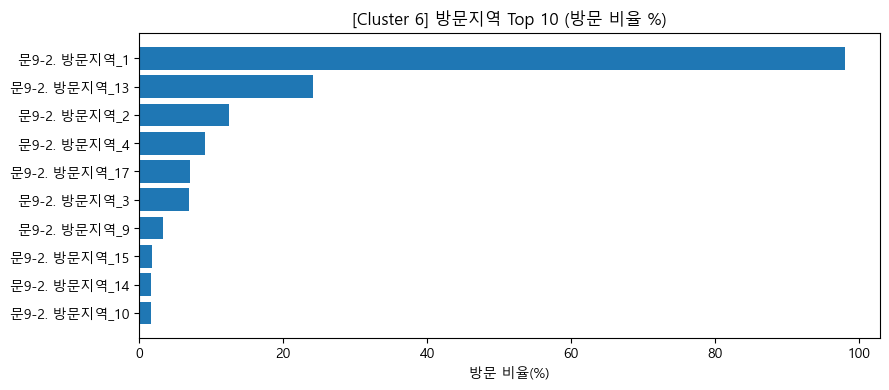

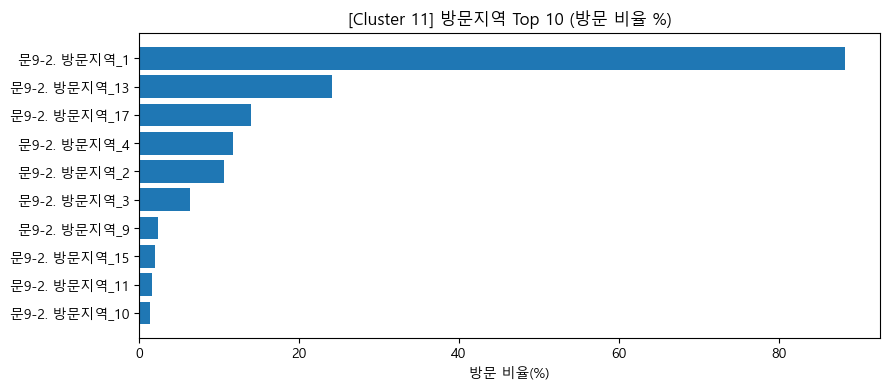


===== Cluster 6 방문지역 조합 Top 10 =====


,Cluster,region_combo,pct
0,6,1,54.55
1,6,1|13,10.95
2,6,1|2,5.75
3,6,1|4,4.27
4,6,1|3,2.97
5,6,1|17,2.41
6,6,1|2|4,2.23
7,6,1|13|17,1.30
8,6,1|2|13,0.93
9,6,1|2|3,0.93



===== Cluster 11 방문지역 조합 Top 10 =====


,Cluster,region_combo,pct
0,11,1,47.24
1,11,1|13,9.10
2,11,1|4,5.74
3,11,17,5.60
4,11,1|2,4.41
5,11,13,3.71
6,11,1|17,2.87
7,11,1|3,2.24
8,11,1|13|17,1.96
9,11,1|2|4,1.89


In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0) 설정
# -----------------------------
target_clusters = [6,11]
cluster_col = "Cluster"

stay_col = "문9-3. 총 체재기간_61일 이상 결측"

region_cols   = [f"문9-2. 방문지역_{i}" for i in range(1, 18)]    # 1~17
activity_cols = [f"문8. 참여한 활동_{i}" for i in range(1, 21)]   # 1~20

topN_region = 10
topN_combo  = 10

# -----------------------------
# 1) 대상 군집 필터링 + 필요한 컬럼만 남기기(속도/안정성 ↑)
# -----------------------------
keep_cols = [cluster_col, stay_col] + region_cols + activity_cols
keep_cols = [c for c in keep_cols if c in df.columns]  # 존재하는 컬럼만

df_t = df.loc[df[cluster_col].isin(target_clusters), keep_cols].copy()

# -----------------------------
# 2) 이진화 함수 (방문지역/활동용)
# -----------------------------
def to_binary_series(s: pd.Series) -> pd.Series:
    s2 = s.replace({
        "Y": 1, "Yes": 1, "예": 1, "선택": 1, "1": 1, 1: 1, True: 1,
        "N": 0, "No": 0, "아니오": 0, "0": 0, 0: 0, False: 0
    })
    return pd.to_numeric(s2, errors="coerce").fillna(0).clip(0, 1).astype(int)

# 실제로 존재하는 region/activity 컬럼만 대상으로
region_cols_exist   = [c for c in region_cols if c in df_t.columns]
activity_cols_exist = [c for c in activity_cols if c in df_t.columns]

# 방문지역/활동 이진화
for c in region_cols_exist:
    df_t[c] = to_binary_series(df_t[c])

for c in activity_cols_exist:
    df_t[c] = to_binary_series(df_t[c])

# -----------------------------
# 3) (A) 군집별 방문지역 Top N 비율 (막대그래프)
# -----------------------------
region_rate = df_t.groupby(cluster_col)[region_cols_exist].mean()

for k in target_clusters:
    if k not in region_rate.index:
        print(f"[WARN] Cluster {k} 데이터가 없습니다.")
        continue

    s = region_rate.loc[k].sort_values(ascending=False).head(topN_region)
    # 가독성을 위해 %로 만들고, barh는 작은 값이 아래로 오게 정렬
    s_pct = (s * 100).round(2).sort_values()

    plt.figure(figsize=(9, 4))
    plt.barh(s_pct.index, s_pct.values)
    plt.title(f"[Cluster {k}] 방문지역 Top {topN_region} (방문 비율 %)")
    plt.xlabel("방문 비율(%)")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 4) (B) 방문지역 '조합' Top N (표로 보기)
#    - 조합 길이가 길면 희귀해지므로, 필요 시 max_len으로 제한 가능
# -----------------------------
def make_combo(row, cols, max_len=None):
    idx = [c.split("_")[-1] for c in cols if row.get(c, 0) == 1]
    if len(idx) == 0:
        return "NONE"
    idx_sorted = sorted(idx, key=lambda x: int(x))
    if max_len is not None:
        idx_sorted = idx_sorted[:max_len]
    return "|".join(idx_sorted)

# (선택) 조합이 너무 길어지는 게 싫으면 max_len=3 같은 식으로 제한
MAX_COMBO_LEN = None  # 예: 3으로 바꾸면 상위 3개 지역까지만 조합으로 봄

df_t["region_combo"] = df_t.apply(lambda r: make_combo(r, region_cols_exist, max_len=MAX_COMBO_LEN), axis=1)

combo_top = (
    df_t.groupby(cluster_col)["region_combo"]
        .value_counts(normalize=True)
        .rename("ratio")
        .reset_index()
)
combo_top["pct"] = (combo_top["ratio"] * 100).round(2)

# 군집별 Top N 조합 출력(퍼센트 기준)
for k in target_clusters:
    print(f"\n===== Cluster {k} 방문지역 조합 Top {topN_combo} =====")
    out = combo_top[combo_top[cluster_col] == k].head(topN_combo).copy()
    # 보기 좋게 컬럼만
    display(out[[cluster_col, "region_combo", "pct"]].reset_index(drop=True))


In [105]:
dd = df[df['Cluster'] == 11]
dd['new_여행패턴'].value_counts()

new_여행패턴
서울 집중형    675
서울 확산형    586
탐험형       168
Name: count, dtype: int64

### Cluster 6

In [106]:
import pandas as pd

# -----------------------------
# Cluster 6 데이터
# -----------------------------
df_c6 = df[df['Cluster'] == 6].copy()

# 참여 활동 컬럼 중 K-컬쳐에 해당하는 번호들
k_culture_idx = [7, 8, 9, 11, 14, 15]
k_culture_cols = [f'문8. 참여한 활동_{i}' for i in k_culture_idx]

# (안전) 값이 '예/선택/Y/1' 등으로 섞여 있어도 0/1로 바꿔주는 함수
def to_binary(s: pd.Series) -> pd.Series:
    return (
        s.replace({
            "예": 1, "선택": 1, "Y": 1, "Yes": 1, 1: 1, True: 1,
            "아니오": 0, "N": 0, "No": 0, 0: 0, False: 0
        })
        .pipe(pd.to_numeric, errors="coerce")
        .fillna(0)
        .clip(0, 1)
        .astype(int)
    )

# 필요한 컬럼이 실제로 존재하는 것만 사용 (혹시 누락 대비)
k_culture_cols_exist = [c for c in k_culture_cols if c in df_c6.columns]

# 0/1 정리
for c in k_culture_cols_exist:
    df_c6[c] = to_binary(df_c6[c])

# K-컬쳐 참여 횟수 (0~6)
df_c6['k_culture_activity_cnt'] = df_c6[k_culture_cols_exist].sum(axis=1)

# (선택) 참여 여부 더미(1개라도 하면 1)
df_c6['k_culture_activity_any'] = (df_c6['k_culture_activity_cnt'] > 0).astype(int)

# 확인
df_c6[['k_culture_activity_cnt', 'k_culture_activity_any']].head()


,k_culture_activity_cnt,k_culture_activity_any
7,3,1
13,0,0
18,2,1
25,0,0
28,0,0


In [107]:
# 방문 지역 컬럼
region_cols = [f'문9-2. 방문지역_{i}' for i in range(1, 18)]

# 서울 포함 여부
df_c6['visit_seoul'] = df_c6[region_cols].apply(
    lambda row: int(any('서울' in str(v) for v in row if pd.notna(v))),
    axis=1
)

df_c6[['k_culture_activity_cnt', 'visit_seoul', '방문 지역 수']].describe()

,k_culture_activity_cnt,visit_seoul,방문 지역 수
count,539.000000,539.0,539.000000
mean,0.892393,0.0,1.693878
std,0.844575,0.0,0.976004
min,0.000000,0.0,1.000000
25%,0.000000,0.0,1.000000
50%,1.000000,0.0,1.000000
75%,1.000000,0.0,2.000000
max,4.000000,0.0,9.000000


In [108]:
print(df_c6['k_culture_activity_any'].value_counts(normalize=True) * 100)
print(df_c6.loc[df_c6['k_culture_activity_any'] == 1,
          'k_culture_activity_cnt'].value_counts(normalize=True).sort_index() * 100)

k_culture_activity_any
1    64.007421
0    35.992579
Name: proportion, dtype: float64
k_culture_activity_cnt
1    68.115942
2    25.507246
3     5.217391
4     1.159420
Name: proportion, dtype: float64


In [109]:
import pandas as pd

# -----------------------------
# K-컬쳐 활동 컬럼 정의
# -----------------------------
k_culture_idx = [7, 8, 9, 11, 14, 15]
k_culture_cols = [f'문8. 참여한 활동_{i}' for i in k_culture_idx]

def to_binary(s: pd.Series) -> pd.Series:
    return (
        s.replace({
            "예": 1, "선택": 1, "Y": 1, "Yes": 1, 1: 1, True: 1,
            "아니오": 0, "N": 0, "No": 0, 0: 0, False: 0
        })
        .pipe(pd.to_numeric, errors="coerce")
        .fillna(0)
        .clip(0, 1)
        .astype(int)
    )

# 실제 존재하는 컬럼만 사용
k_culture_cols_exist = [c for c in k_culture_cols if c in df.columns]

for c in k_culture_cols_exist:
    df[c] = to_binary(df[c])

# K-컬쳐 참여 횟수
df['k_culture_activity_cnt'] = df[k_culture_cols_exist].sum(axis=1)

# K-컬쳐 참여 여부
df['k_culture_activity_any'] = (df['k_culture_activity_cnt'] > 0).astype(int)


In [110]:
cluster_any_ratio = (
    df
    .groupby('Cluster')['k_culture_activity_any']
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

cluster_any_ratio


Cluster
6     64.0
11    63.3
5     61.0
4     55.5
7     55.2
10    53.9
3     53.5
8     51.7
2     45.9
1     45.8
9     39.4
Name: k_culture_activity_any, dtype: float64

In [111]:
cluster_cnt_mean = (
    df
    .groupby('Cluster')['k_culture_activity_cnt']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

cluster_cnt_mean


Cluster
6     0.89
11    0.85
5     0.82
4     0.75
10    0.72
7     0.71
3     0.66
8     0.61
2     0.60
1     0.54
9     0.48
Name: k_culture_activity_cnt, dtype: float64

### 각 비율 확인

In [112]:
k_culture_idx = [5,6,7,8, 9, 10, 11, 15,16]
k_culture_cols = [f'문8. 참여한 활동_{i}' for i in k_culture_idx]

# 실제 존재하는 컬럼만
k_culture_cols = [c for c in k_culture_cols if c in df.columns]


def to_binary(s):
    return (
        s.replace({
            "예": 1, "선택": 1, "Y": 1, "Yes": 1, 1: 1, True: 1,
            "아니오": 0, "N": 0, "No": 0, 0: 0, False: 0
        })
        .pipe(pd.to_numeric, errors="coerce")
        .fillna(0)
        .clip(0, 1)
        .astype(int)
    )

for c in k_culture_cols:
    df[c] = to_binary(df[c])

    cluster_activity_ratio = (
    df
    .groupby('Cluster')[k_culture_cols]
    .mean()
    .mul(100)
    .round(1)
)

cluster_activity_ratio

# 8 : k-pop
# 11 : 유흥

,문8. 참여한 활동_5,문8. 참여한 활동_6,문8. 참여한 활동_7,문8. 참여한 활동_8,문8. 참여한 활동_9,문8. 참여한 활동_10,문8. 참여한 활동_11,문8. 참여한 활동_15,문8. 참여한 활동_16
Cluster,,,,,,,,,
1,45.4,19.3,29.3,8.6,1.6,4.2,10.0,1.6,2.2
2,36.7,15.8,18.8,12.4,4.5,4.0,13.8,2.1,2.6
3,29.0,13.5,12.6,29.7,7.5,1.6,7.7,1.1,1.1
4,61.5,31.2,35.5,12.2,7.7,6.2,12.5,2.7,8.5
5,71.0,40.9,46.8,8.2,4.7,6.9,15.4,3.0,3.3
6,67.0,37.1,39.7,18.7,6.5,8.3,16.3,2.2,3.5
7,63.3,32.2,38.1,8.4,5.0,5.5,13.6,1.9,2.5
8,63.3,27.6,38.1,5.3,2.8,5.1,9.0,1.9,1.6
9,28.7,8.8,11.9,5.4,3.3,1.5,12.5,1.5,1.5


In [113]:
import pandas as pd

# K-컬쳐 활동 코드
k_culture_codes = [5, 6, 7, 8, 9, 10, 11, 15, 16]

# 만족한 활동 컬럼들
sat_cols = [f'문8-1. 만족한 활동_{i}' for i in range(1, 4)]
sat_cols = [c for c in sat_cols if c in df.columns]
df['k_culture_satisfied_any'] = (
    df[sat_cols]
    .apply(lambda row: int(any(v in k_culture_codes for v in row if pd.notna(v))), axis=1)
)

cluster_kculture_satis_ratio = (
    df
    .groupby('Cluster')['k_culture_satisfied_any']
    .mean()
    .mul(100)
    .round(1)
)

cluster_kculture_satis_ratio


Cluster
1     59.0
2     51.8
3     56.8
4     69.3
5     74.5
6     76.3
7     66.7
8     67.5
9     40.0
10    66.0
11    75.6
Name: k_culture_satisfied_any, dtype: float64

In [114]:
from collections import Counter

def get_code_ratio(df_sub, col, codes):
    total = len(df_sub)
    cnt = sum(df_sub[col].isin(codes))
    return round(cnt / total * 100, 1)

rows = []

for cl, g in df.groupby('Cluster'):
    row = {'Cluster': cl}
    for code in k_culture_codes:
        row[f'범주_{code}'] = (
            g[sat_cols]
            .apply(lambda r: int(code in r.values), axis=1)
            .mean() * 100
        )
    rows.append(row)

cluster_sat_detail = pd.DataFrame(rows).set_index('Cluster').round(1)
cluster_sat_detail


,범주_5,범주_6,범주_7,범주_8,범주_9,범주_10,범주_11,범주_15,범주_16
Cluster,,,,,,,,,
1,31.9,11.2,14.7,6.4,0.8,1.4,6.0,1.4,1.8
2,24.5,8.1,6.8,9.5,3.2,2.4,8.1,1.5,1.9
3,19.2,7.7,5.2,26.1,6.3,0.7,4.5,0.6,0.8
4,37.8,15.9,16.9,8.6,3.1,2.6,6.6,1.3,5.7
5,50.6,21.3,18.7,4.5,2.1,2.2,7.0,1.1,1.8
6,46.2,20.0,16.5,12.6,3.3,3.5,7.6,0.9,2.6
7,45.2,16.4,16.2,5.3,2.8,1.6,6.3,1.3,1.6
8,46.9,16.2,18.1,2.8,1.9,2.6,3.9,0.9,1.2
9,20.4,5.0,5.2,3.3,2.1,1.0,9.6,0.8,0.4


### Cluster 7

In [115]:
df_c7 = df[df['Cluster'] == 7].copy()


## ① 체류기간 × 지출경비 (가장 중요)

# 요약 통계
df_c7[['문9-3. 총 체재기간_61일 이상 결측',
       '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)']].describe()


,문9-3. 총 체재기간_61일 이상 결측,"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)"
count,872.000000,872.000000
mean,6.434633,332.952729
std,3.672637,244.509340
min,1.000000,22.000000
25%,4.000000,201.652665
50%,5.000000,276.496575
75%,7.000000,362.750000
max,36.000000,1687.500000


In [116]:
df[['문9-3. 총 체재기간_61일 이상 결측',
    '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)']].mean()


문9-3. 총 체재기간_61일 이상 결측                     6.592722
문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)    315.529950
dtype: float64

In [117]:
activity_cols = [f'문8. 참여한 활동_{i}' for i in range(1, 21)]
activity_cols = [c for c in activity_cols if c in df.columns]

def to_binary(s):
    return (
        s.replace({
            "예": 1, "선택": 1, "Y": 1, "Yes": 1, 1: 1, True: 1,
            "아니오": 0, "N": 0, "No": 0, 0: 0, False: 0
        })
        .pipe(pd.to_numeric, errors="coerce")
        .fillna(0)
        .clip(0, 1)
        .astype(int)
    )

for c in activity_cols:
    df_c7[c] = to_binary(df_c7[c])

# 활동별 참여 비율(%)
activity_ratio_c7 = (
    df_c7[activity_cols]
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

activity_ratio_c7

문8. 참여한 활동_2     85.9
문8. 참여한 활동_1     82.3
문8. 참여한 활동_3     71.3
문8. 참여한 활동_5     63.3
문8. 참여한 활동_7     38.1
문8. 참여한 활동_6     32.2
문8. 참여한 활동_4     20.3
문8. 참여한 활동_12    18.8
문8. 참여한 활동_11    13.6
문8. 참여한 활동_13    11.2
문8. 참여한 활동_8      8.4
문8. 참여한 활동_10     5.5
문8. 참여한 활동_9      5.0
문8. 참여한 활동_14     4.0
문8. 참여한 활동_16     2.5
문8. 참여한 활동_15     1.9
문8. 참여한 활동_17     0.9
문8. 참여한 활동_18     0.7
문8. 참여한 활동_19     0.6
문8. 참여한 활동_20     0.1
dtype: float64

In [118]:
# 1. 전체 데이터(df)에 대해 전처리 적용
# (df_c7이 아닌 전체 df를 대상으로 진행해야 비교가 가능합니다)
for c in activity_cols:
    df[c] = to_binary(df[c])

# 2. 클러스터별 활동 평균(비율) 계산
cluster_activity_means = df.groupby('Cluster')[activity_cols].mean().mul(100)

# 3. 클러스터 7과 '전체 평균' 비교 데이터프레임 만들기
comparison_df = pd.DataFrame({
    'Cluster_7_Ratio': cluster_activity_means.loc[6],
    'Overall_Average': df[activity_cols].mean().mul(100)
})

# 4. '상승도(Lift)' 계산: 전체 평균 대비 클러스터 7이 몇 배나 더 많이 하는가?
comparison_df['Lift'] = comparison_df['Cluster_7_Ratio'] / comparison_df['Overall_Average']
comparison_df = comparison_df.sort_values(by='Lift', ascending=False)

print(" [클러스터 7의 특징적 활동 (전체 대비 비율)] ")
comparison_df.head(10)

 [클러스터 7의 특징적 활동 (전체 대비 비율)] 


,Cluster_7_Ratio,Overall_Average,Lift
문8. 참여한 활동_18,1.298701,0.709787,1.829706
문8. 참여한 활동_17,1.113173,0.619814,1.795978
문8. 참여한 활동_19,1.298701,0.749775,1.732121
문8. 참여한 활동_10,8.348794,5.158452,1.618469
문8. 참여한 활동_20,0.556586,0.379886,1.465140
문8. 참여한 활동_8,18.738404,13.945816,1.343658
문8. 참여한 활동_6,37.105751,27.821654,1.333700
문8. 참여한 활동_7,39.703154,31.470559,1.261597
문8. 참여한 활동_5,66.975881,53.693892,1.247365
문8. 참여한 활동_9,6.493506,5.208437,1.246728


In [119]:
region_cols = [f'문9-2. 방문지역_{i}' for i in range(1, 18)]
region_cols = [c for c in region_cols if c in df.columns]

# 서울 방문 여부
df_c7['visit_seoul'] = df_c7[region_cols].apply(
    lambda row: int(any('서울' in str(v) for v in row if pd.notna(v))),
    axis=1
)

df_c7[['visit_seoul', '방문 지역 수']].mean().mul(100).round(1)

visit_seoul      0.0
방문 지역 수        148.9
dtype: float64

In [120]:
df_c7['여행동반자_그룹'].value_counts(normalize=True).mul(100).round(1)

여행동반자_그룹
가족형           40.0
친구형           30.8
혼자형            8.5
단체형            8.3
직장형            7.6
복합형(가족+친구)     4.4
기타형            0.5
Name: proportion, dtype: float64

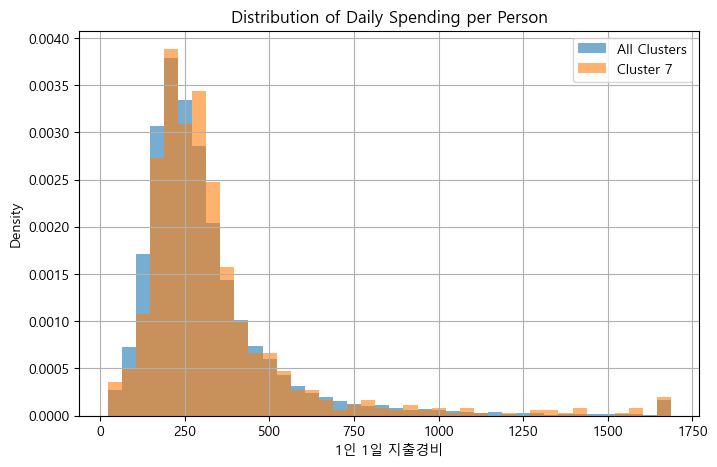

In [121]:
col = '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'
# 전체 데이터 (결측 제거)
all_data = df[col].dropna()

# Cluster 7 데이터
c7_data = df[df['Cluster'] == 7][col].dropna()
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(all_data, bins=40, alpha=0.6, density=True, label='All Clusters')
plt.hist(c7_data, bins=40, alpha=0.6, density=True, label='Cluster 7')

plt.xlabel('1인 1일 지출경비')
plt.ylabel('Density')
plt.title('Distribution of Daily Spending per Person')
plt.legend()
plt.grid(True)

plt.show()

### Cluster 11

In [122]:
df_c11 = df[df['Cluster'] == 11].copy()
# 방문 지역 수 분포 (%)
df_c11['방문 지역 수'].value_counts(normalize=True).sort_index().mul(100).round(1)

방문 지역 수
1     57.4
2     26.9
3     11.1
4      2.9
5      1.1
6      0.3
7      0.1
8      0.1
13     0.1
Name: proportion, dtype: float64

In [123]:
df['방문 지역 수'].value_counts(normalize=True).sort_index().mul(100).round(1)

방문 지역 수
0      0.0
1     66.4
2     23.6
3      7.0
4      2.0
5      0.6
6      0.1
7      0.1
8      0.0
9      0.0
13     0.0
Name: proportion, dtype: float64

In [124]:
cols = [
    '문9-3. 총 체재기간_61일 이상 결측',
    '문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)'
]

# 클러스터 11
df_c11[cols].describe()

,문9-3. 총 체재기간_61일 이상 결측,"문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)"
count,1429.000000,1429.000000
mean,7.226732,296.674295
std,4.662604,212.324350
min,2.000000,22.000000
25%,5.000000,181.500000
50%,6.000000,246.033333
75%,8.000000,339.000000
max,56.000000,1687.500000


In [125]:
df[cols].mean()

문9-3. 총 체재기간_61일 이상 결측                     6.592722
문10. 1인 1일 지출경비(상하위 1% 대체, 61일 이상 결측)    315.529950
dtype: float64

In [126]:
region_cols = [f'문9-2. 방문지역_{i}' for i in range(1, 18)]
region_cols = [c for c in region_cols if c in df.columns]

df_c11['visit_seoul'] = df_c11[region_cols].apply(
    lambda row: int(any('서울' in str(v) for v in row if pd.notna(v))),
    axis=1
)

df_c11['visit_seoul'].value_counts(normalize=True).mul(100).round(1)

visit_seoul
0    100.0
Name: proportion, dtype: float64

In [127]:
df_c11['여행동반자_그룹'].value_counts(normalize=True).mul(100).round(1)

여행동반자_그룹
가족형           45.4
친구형           26.6
혼자형           16.3
단체형            8.1
직장형            1.7
복합형(가족+친구)     1.6
기타형            0.3
Name: proportion, dtype: float64

In [128]:
activity_cols = [f'문8. 참여한 활동_{i}' for i in range(1, 21)]
activity_cols = [c for c in activity_cols if c in df.columns]

def to_binary(s):
    return (
        s.replace({
            "예": 1, "선택": 1, "Y": 1, "Yes": 1, 1: 1, True: 1,
            "아니오": 0, "N": 0, "No": 0, 0: 0, False: 0
        })
        .pipe(pd.to_numeric, errors="coerce")
        .fillna(0)
        .clip(0, 1)
        .astype(int)
    )

for c in activity_cols:
    df_c11[c] = to_binary(df_c11[c])

# 활동 참여 개수 분포
df_c11['activity_cnt'] = df_c11[activity_cols].sum(axis=1)
df_c11['activity_cnt'].describe()

count    1429.000000
mean        4.974108
std         1.923619
min         1.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        14.000000
Name: activity_cnt, dtype: float64

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 클러스터 11 데이터만 필터링
df_c11 = df[df['Cluster'] == 11].copy()

# 2. 이진화 전처리 (방문지역 컬럼)
region_cols = [f"문9-2. 방문지역_{i}" for i in range(1, 18)]
region_cols_exist = [c for c in region_cols if c in df_c11.columns]

def to_binary(s):
    return pd.to_numeric(s.replace({"Y":1, "Yes":1, "예":1, "선택":1, "N":0, "No":0, "아니오":0}), errors='coerce').fillna(0).clip(0,1).astype(int)

for c in region_cols_exist:
    df_c11[c] = to_binary(df_c11[c])

# 3. 분석용 파생 변수 생성
# - 방문한 지역 번호들을 리스트로 추출 (예: [1, 2, 5])
df_c11['visit_list'] = df_c11[region_cols_exist].apply(lambda row: [int(c.split('_')[-1]) for c in region_cols_exist if row[c] == 1], axis=1)
# - 방문한 지역의 총 개수
df_c11['visit_count'] = df_c11['visit_list'].apply(len)
# - 조합을 문자열로 변환 (정렬 포함)
df_c11['visit_combo'] = df_c11['visit_list'].apply(lambda x: "|".join(map(str, sorted(x))) if x else "NONE")

# ---------------------------------------------------------
# 4. 결과 출력 1: 방문 지역 개수 분포 (이동성 확인)
# ---------------------------------------------------------
print("===== [Cluster 11] 방문 지역 수 분포 =====")
print(df_c11['visit_count'].value_counts(normalize=True).mul(100).round(1).sort_index())

# ---------------------------------------------------------
# 5. 결과 출력 2: Top 10 방문 조합 (단독/조합 모두 포함)
# ---------------------------------------------------------
print("\n===== [Cluster 11] Top 10 방문 지역 조합 =====")
combo_rank = df_c11['visit_combo'].value_counts(normalize=True).head(10).mul(100).round(1)
print(combo_rank)

# ---------------------------------------------------------
# 6. 결과 출력 3: '서울(1)'을 포함한 확산 패턴 상세 분석
# ---------------------------------------------------------
# 서울을 방문한 사람 중 다른 지역도 간 사람 필터링
seoul_visitors = df_c11[df_c11['visit_list'].apply(lambda x: 1 in x)]
only_seoul = seoul_visitors[seoul_visitors['visit_count'] == 1]
seoul_plus_others = seoul_visitors[seoul_visitors['visit_count'] > 1]

print(f"\n===== [Cluster 11] 서울 방문자 분석 (전체 {len(seoul_visitors)}명) =====")
print(f"- 서울만 방문: {len(only_seoul)}명 ({len(only_seoul)/len(seoul_visitors)*100:.1f}%)")
print(f"- 서울 + 타지역(확산형): {len(seoul_plus_others)}명 ({len(seoul_plus_others)/len(seoul_visitors)*100:.1f}%)")

if not seoul_plus_others.empty:
    print("\n[서울과 함께 가장 많이 방문한 지역 Top 5]")
    # 서울을 제외하고 어떤 지역을 같이 갔는지 카운트
    other_regions = []
    seoul_plus_others['visit_list'].apply(lambda x: other_regions.extend([r for r in x if r != 1]))
    print(pd.Series(other_regions).value_counts().head(5))

===== [Cluster 11] 방문 지역 수 분포 =====
visit_count
1     57.4
2     26.9
3     11.1
4      2.9
5      1.1
6      0.3
7      0.1
8      0.1
13     0.1
Name: proportion, dtype: float64

===== [Cluster 11] Top 10 방문 지역 조합 =====
visit_combo
1          47.2
1|13        9.1
1|4         5.7
17          5.6
1|2         4.4
13          3.7
1|17        2.9
1|3         2.2
1|13|17     2.0
1|2|4       1.9
Name: proportion, dtype: float64

===== [Cluster 11] 서울 방문자 분석 (전체 1261명) =====
- 서울만 방문: 675명 (53.5%)
- 서울 + 타지역(확산형): 586명 (46.5%)

[서울과 함께 가장 많이 방문한 지역 Top 5]
13    270
4     166
2     147
17    117
3      84
Name: count, dtype: int64


In [130]:
# 클러스터 11의 'new_여행패턴' 분포 확인
print("----- [Cluster 11] 여행패턴 라벨 분포 -----")
print(df_c11['new_여행패턴'].value_counts(normalize=True).mul(100).round(1))

# '서울 확산형' 라벨을 가진 사람들의 실제 방문 지역 개수
seoul_diffusion_labeled = df_c11[df_c11['new_여행패턴'] == '서울 확산형'] # 실제 컬럼 내 텍스트로 수정 필요

print("\n----- '서울 확산형' 라벨자들의 실제 방문 지역 수 -----")
print(seoul_diffusion_labeled['visit_count'].value_counts(normalize=True).mul(100).round(1))

# 수도권(서울1, 인천2, 경기3) 안에서만 움직였는지 확인
def check_metropolitan(v_list):
    metro_codes = {1, 2, 3}
    # 방문지가 모두 metro_codes 안에 있고, 최소 1개 이상 방문했을 때
    return set(v_list).issubset(metro_codes) and len(v_list) > 0

df_c11['is_metro_only'] = df_c11['visit_list'].apply(check_metropolitan)

print("\n----- 수도권(서울/인천/경기) 내에서만 이동한 비율 -----")
print(df_c11['is_metro_only'].value_counts(normalize=True).mul(100).round(1))

----- [Cluster 11] 여행패턴 라벨 분포 -----
new_여행패턴
서울 집중형    47.2
서울 확산형    41.0
탐험형       11.8
Name: proportion, dtype: float64

----- '서울 확산형' 라벨자들의 실제 방문 지역 수 -----
visit_count
2     61.6
3     27.1
4      7.2
5      2.7
6      0.7
7      0.3
8      0.2
13     0.2
Name: proportion, dtype: float64

----- 수도권(서울/인천/경기) 내에서만 이동한 비율 -----
is_metro_only
True     55.1
False    44.9
Name: proportion, dtype: float64


In [131]:
# Cluster 11에 대해서만 다시 한번 생데이터 카운트
real_check = df[df['Cluster'] == 11]['new_여행패턴'].value_counts(dropna=False)
real_pct = df[df['Cluster'] == 11]['new_여행패턴'].value_counts(normalize=True, dropna=False) * 100

print("----- [Cluster 11] 실시간 데이터 검증 -----")
for idx in real_check.index:
    print(f"{idx}: {real_check[idx]}명 ({real_pct[idx]:.1f}%)")

# 전체 Cluster 11의 총 행(Row) 수도 확인해봅시다.
print(f"\nCluster 11 전체 데이터 수: {len(df[df['Cluster'] == 11])}행")

----- [Cluster 11] 실시간 데이터 검증 -----
서울 집중형: 675명 (47.2%)
서울 확산형: 586명 (41.0%)
탐험형: 168명 (11.8%)

Cluster 11 전체 데이터 수: 1429행
